

# **PRACTICA 3 MINERÍA PREDICTIVA**


## Objetivo
Predecir el puntaje global de Saber 11 (`punt_global`) a partir de características del colegio y del estudiante.

In [4]:
#Cargamos librerías principales
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# **Preparación de Datos**


In [5]:
# Se cargan los datos de la tabla 1
data = pd.read_excel("datos_saber.xlsx")
data.head()

,periodo,estu_tipodocumento,estu_consecutivo,cole_area_ubicacion,cole_bilingue,cole_calendario,cole_caracter,cole_cod_dane_establecimiento,cole_cod_dane_sede,cole_cod_depto_ubicacion,...,fami_tienecomputador,fami_tieneinternet,fami_tienelavadora,desemp_ingles,punt_ingles,punt_matematicas,punt_sociales_ciudadanas,punt_c_naturales,punt_lectura_critica,punt_global
0,20224,TI,SB11202240616361,URBANO,NaN,A,NaN,311001800821,311001800821,11,...,Si,Si,Si,A1,56.0,63,56,55,46,275
1,20224,CC,SB11202240616360,URBANO,NaN,A,NaN,311001800821,311001800821,11,...,Si,Si,Si,B1,73.0,55,59,59,63,300
2,20224,TI,SB11202240616359,URBANO,N,A,TÉCNICO/ACADÉMICO,125488000133,125488000133,25,...,No,No,Si,A2,63.0,63,72,69,60,329
3,20224,TI,SB11202240616358,URBANO,N,A,ACADÉMICO,105001007978,105001007978,5,...,Si,No,No,A-,40.0,38,36,45,45,205
4,20224,TI,SB11202240616357,RURAL,NaN,A,TÉCNICO,215469000342,215469000342,15,...,No,Si,Si,A1,52.0,44,38,46,37,210


In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 51 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   periodo                        1000 non-null   int64  
 1   estu_tipodocumento             1000 non-null   object 
 2   estu_consecutivo               1000 non-null   object 
 3   cole_area_ubicacion            1000 non-null   object 
 4   cole_bilingue                  674 non-null    object 
 5   cole_calendario                1000 non-null   object 
 6   cole_caracter                  867 non-null    object 
 7   cole_cod_dane_establecimiento  1000 non-null   int64  
 8   cole_cod_dane_sede             1000 non-null   int64  
 9   cole_cod_depto_ubicacion       1000 non-null   int64  
 10  cole_cod_mcpio_ubicacion       1000 non-null   int64  
 11  cole_codigo_icfes              1000 non-null   int64  
 12  cole_depto_ubicacion           1000 non-null   ob

In [7]:
#Revisamos si tenemos ID repetidos
ids = data['estu_consecutivo'].value_counts()
ids[ids > 1]

,count
estu_consecutivo,


No existen Id´s repetidos

In [8]:
#Corrección del tipo de datos object a categorías
cols_categoricas = [
    'periodo',
    'cole_cod_dane_establecimiento',
    'cole_cod_dane_sede',
    'cole_cod_depto_ubicacion',
    'cole_cod_mcpio_ubicacion',
    'cole_codigo_icfes',
    'estu_cod_depto_presentacion',
    'estu_cod_mcpio_presentacion',
    'estu_tipodocumento',
    'estu_consecutivo',
    'cole_area_ubicacion',
    'cole_bilingue',
    'cole_calendario',
    'cole_caracter',
    'cole_depto_ubicacion',
    'cole_genero',
    'cole_jornada',
    'cole_mcpio_ubicacion',
    'cole_naturaleza',
    'cole_nombre_establecimiento',
    'cole_nombre_sede',
    'cole_sede_principal',
    'estu_depto_presentacion',
    'estu_depto_reside',
    'estu_estadoinvestigacion',
    'estu_estudiante',
    'estu_fechanacimiento',
    'estu_genero',
    'estu_mcpio_presentacion',
    'estu_mcpio_reside',
    'estu_nacionalidad',
    'estu_pais_reside',
    'estu_privado_libertad',
    'fami_educacionmadre',
    'fami_educacionpadre',
    'fami_estratovivienda',
    'fami_tieneautomovil',
    'fami_tienecomputador',
    'fami_tieneinternet',
    'fami_tienelavadora',
    'desemp_ingles',
]

cols_categoricas_codigos_float = [
    'estu_cod_reside_depto',
    'estu_cod_reside_mcpio',
]

data[cols_categoricas_codigos_float] = data[cols_categoricas_codigos_float].astype('Int64').astype('category')

data[cols_categoricas] = data[cols_categoricas].astype('category')


In [9]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 51 columns):
 #   Column                         Non-Null Count  Dtype   
---  ------                         --------------  -----   
 0   periodo                        1000 non-null   category
 1   estu_tipodocumento             1000 non-null   category
 2   estu_consecutivo               1000 non-null   category
 3   cole_area_ubicacion            1000 non-null   category
 4   cole_bilingue                  674 non-null    category
 5   cole_calendario                1000 non-null   category
 6   cole_caracter                  867 non-null    category
 7   cole_cod_dane_establecimiento  1000 non-null   category
 8   cole_cod_dane_sede             1000 non-null   category
 9   cole_cod_depto_ubicacion       1000 non-null   category
 10  cole_cod_mcpio_ubicacion       1000 non-null   category
 11  cole_codigo_icfes              1000 non-null   category
 12  cole_depto_ubicacion           1000

2. Eliminar variables irrelevantes y redundantes



In [10]:
# Variables irrelevantes para el proceso de minería

cols_a_eliminar = [
    # Completamente vacías
    'fami_cuartoshogar',
    'fami_personashogar',

    'estu_consecutivo',
    'cole_codigo_icfes',
    'cole_cod_dane_establecimiento',
    'cole_cod_dane_sede',
    'cole_cod_depto_ubicacion',
    'cole_cod_mcpio_ubicacion',
    'estu_cod_depto_presentacion',
    'estu_cod_mcpio_presentacion',
    'estu_cod_reside_depto',
    'estu_cod_reside_mcpio',
    'cole_nombre_establecimiento',
    'cole_nombre_sede',
    'estu_tipodocumento',
    'estu_estadoinvestigacion',
    'estu_estudiante',
    'estu_privado_libertad',
    'estu_nacionalidad',
    'estu_pais_reside',
    'periodo',
    'estu_depto_presentacion',
    'estu_depto_reside',
    'estu_fechanacimiento',
    'estu_mcpio_presentacion',
    'estu_mcpio_reside',
    'cole_depto_ubicacion',
    'cole_genero',
    'cole_mcpio_ubicacion',
    'cole_sede_principal',
    'desemp_ingles',
    'punt_ingles',
    'punt_matematicas',
    'punt_sociales_ciudadanas',
    'punt_c_naturales',
    'punt_lectura_critica',
    'fami_educacionmadre',
    'fami_educacionpadre',
    'fami_tieneautomovil',
    'fami_tienecomputador',
    'fami_tieneinternet',
    'fami_tienelavadora',
]

data = data.drop(cols_a_eliminar, axis=1)

data.head()

,cole_area_ubicacion,cole_bilingue,cole_calendario,cole_caracter,cole_jornada,cole_naturaleza,estu_genero,fami_estratovivienda,punt_global
0,URBANO,NaN,A,NaN,UNICA,NO OFICIAL,M,Estrato 4,275
1,URBANO,NaN,A,NaN,UNICA,NO OFICIAL,M,Estrato 3,300
2,URBANO,N,A,TÉCNICO/ACADÉMICO,UNICA,OFICIAL,M,Estrato 1,329
3,URBANO,N,A,ACADÉMICO,MAÑANA,OFICIAL,F,Estrato 2,205
4,RURAL,NaN,A,TÉCNICO,COMPLETA,OFICIAL,M,Estrato 2,210


In [11]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column                Non-Null Count  Dtype   
---  ------                --------------  -----   
 0   cole_area_ubicacion   1000 non-null   category
 1   cole_bilingue         674 non-null    category
 2   cole_calendario       1000 non-null   category
 3   cole_caracter         867 non-null    category
 4   cole_jornada          1000 non-null   category
 5   cole_naturaleza       1000 non-null   category
 6   estu_genero           997 non-null    category
 7   fami_estratovivienda  908 non-null    category
 8   punt_global           1000 non-null   int64   
dtypes: category(8), int64(1)
memory usage: 17.1 KB


Quedan las columnas verdaderamente relevantes

3. Descripción estadística

**Variables numéricas**

In [12]:
data.describe()

,punt_global
count,1000.000000
mean,228.416000
std,49.224526
min,0.000000
25%,190.000000
50%,221.000000
75%,263.000000
max,413.000000


array([[<Axes: title={'center': 'punt_global'}>]], dtype=object)

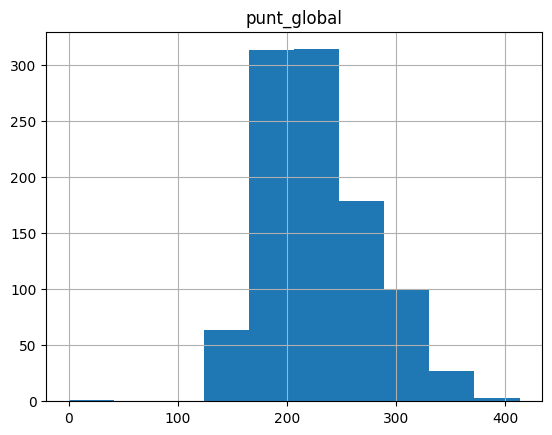

In [13]:
data.hist()

<Axes: >

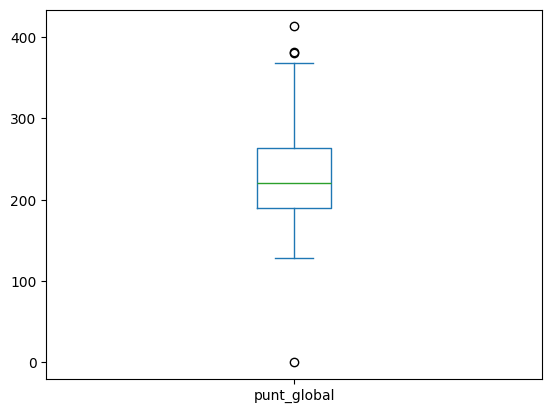

In [14]:
data.plot.box()

No hay ningun valor atipido en la variable numerica

**Variables categóricas** (value_counts())

<Axes: xlabel='cole_area_ubicacion'>

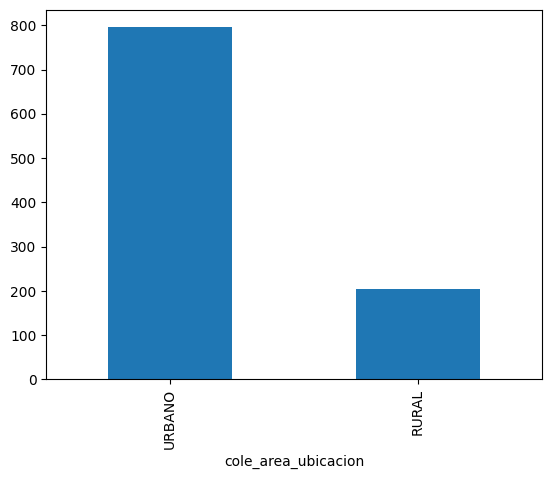

In [15]:
data['cole_area_ubicacion'].value_counts().plot(kind='bar')

<Axes: xlabel='cole_bilingue'>

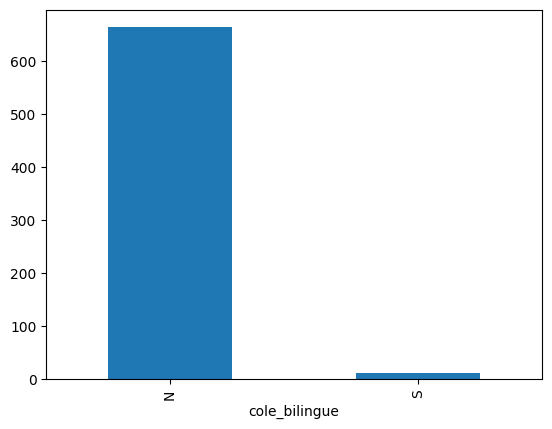

In [16]:
data['cole_bilingue'].value_counts().plot(kind='bar')

<Axes: xlabel='cole_calendario'>

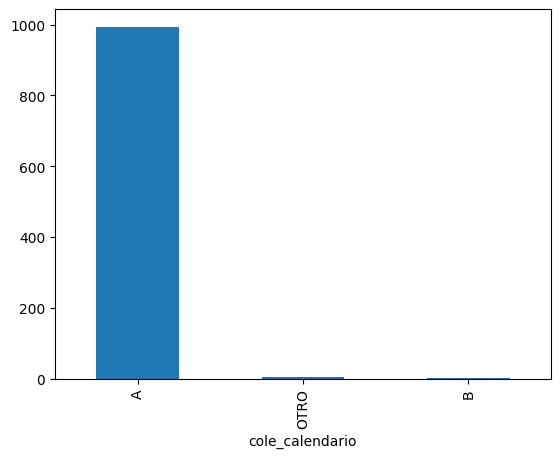

In [17]:
data['cole_calendario'].value_counts().plot(kind='bar')

<Axes: xlabel='cole_caracter'>

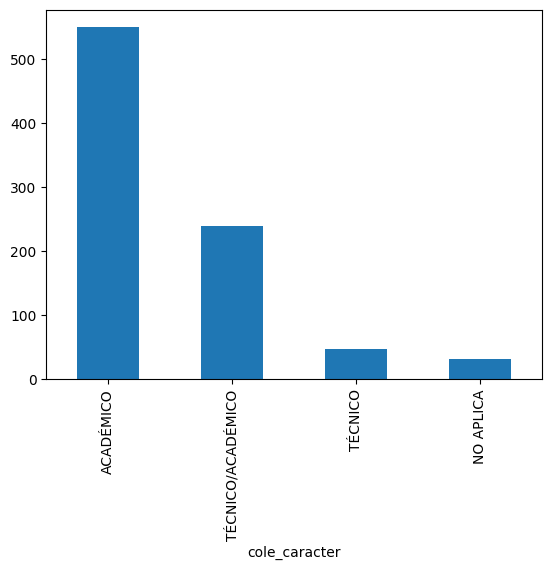

In [18]:
data['cole_caracter'].value_counts().plot(kind='bar')

<Axes: xlabel='cole_jornada'>

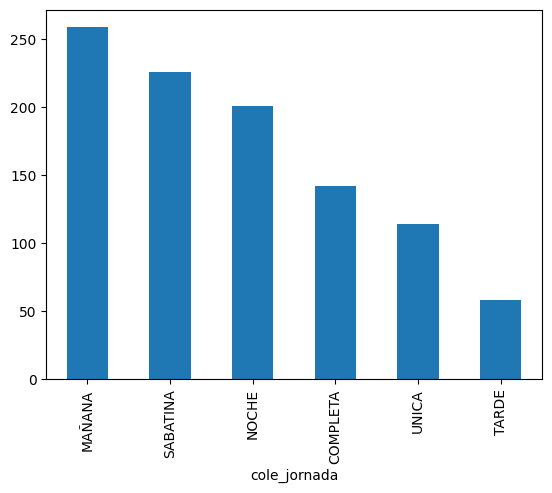

In [19]:
data['cole_jornada'].value_counts().plot(kind='bar')

<Axes: xlabel='cole_naturaleza'>

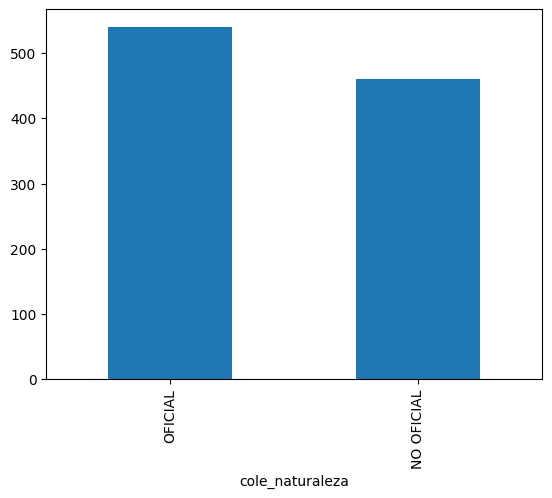

In [20]:
data['cole_naturaleza'].value_counts().plot(kind='bar')

<Axes: xlabel='estu_genero'>

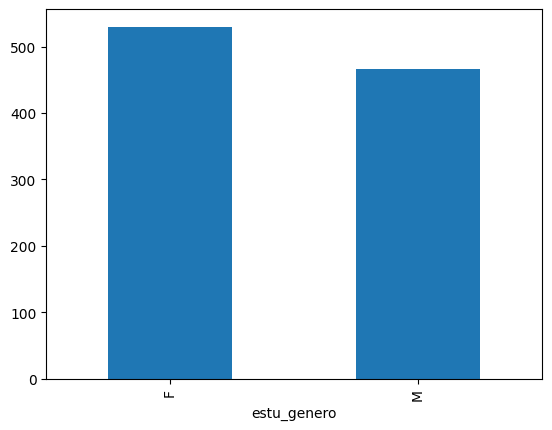

In [21]:
data['estu_genero'].value_counts().plot(kind='bar')

<Axes: xlabel='fami_estratovivienda'>

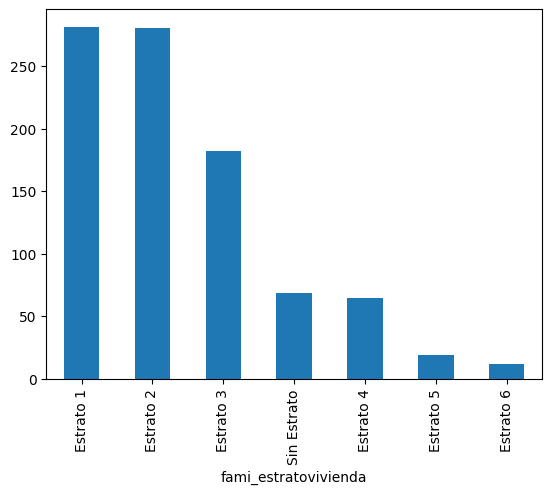

In [22]:
data['fami_estratovivienda'].value_counts().plot(kind='bar')

**Gráficas de las relaciones entre variables**

array([[<Axes: xlabel='punt_global', ylabel='punt_global'>]], dtype=object)

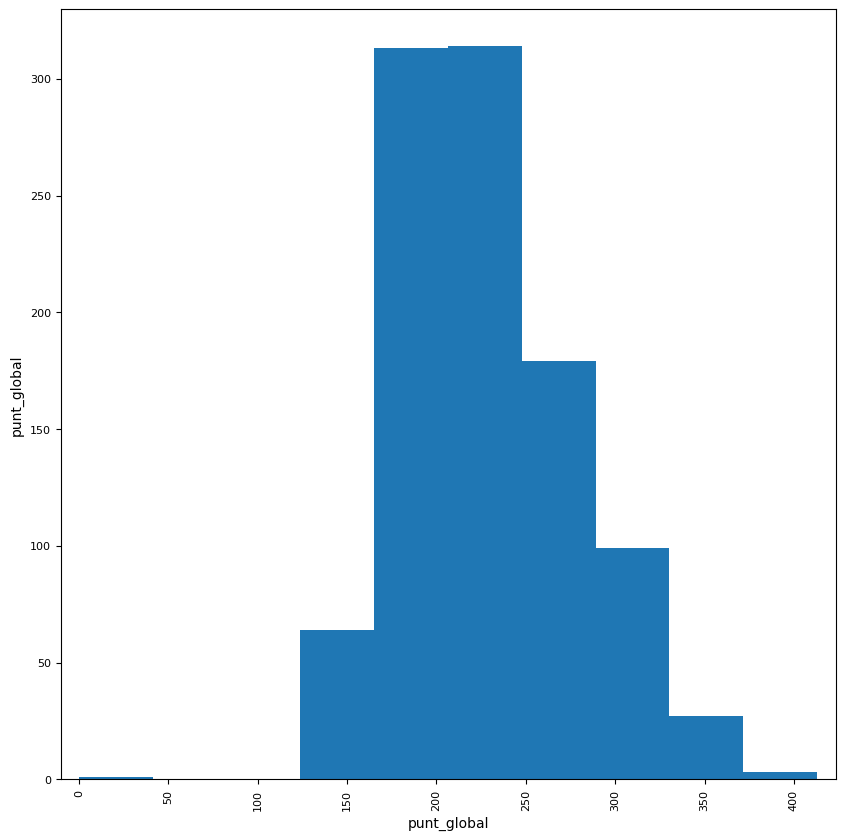

In [23]:
# Gráficas para identificar relaciones entre las variables
pd.plotting.scatter_matrix(data, figsize=(10,10))
# Si alguna de estas graficas se ve como una linea recta perfecta, significa que esas variables podrían ser redundantes

**Perfilado de datos**

In [24]:
!pip install ydata-profiling

from ydata_profiling import ProfileReport

profile_data=ProfileReport(data, minimal=True) # minimal=True
profile_data

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 9/9 [00:00<00:00, 204.54it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

In [25]:
#Guardamos en html el perfilado de datos
profile_data.to_file(output_file="output.html")

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

 **Diagnóstico de las dimensiones según el perfilado:**
* **Completitud:**
  - Existen missing en cole_bilingue: 326 - 32.6%
  - Existen missing en cole_caracter: 133 - 13.3%
  - Existen missing en estu_genero: 3 - 0.3%
  - Existen missing en fami_estratovivienda: 92 - 9.2%

* **Exactitud:** no existen errores en ninguno de las variables
* **Conformidad:** el formato de las variables es conforme a lo esperado
* **Oportunidad:** a pesar de que anteriormente se eliminó la columna "periodo" relacionado con la fecha, se puede decir que los datos sin son oportunos, ya que pertenecen al año 2022
* **Duplicidad:** no había casos de duplicidad en los datos
* **Integridad:** no hay problemas de integridad

4. Limpieza de datos atípicos-errores
- Sólo se limpian errores

In [26]:
data.describe()

,punt_global
count,1000.000000
mean,228.416000
std,49.224526
min,0.000000
25%,190.000000
50%,221.000000
75%,263.000000
max,413.000000


No hay valores atípicos

**5. Limpieza de datos nulos: Imputación**

Estrategia:
* Eliminar registros con mas de 15% de nulos
* Eliminar columnas con mas de 15%-20% de nulos
* Imputar por media, moda, mediana, vecinos cercanos. No se puede imputar más allá del 15% de los datos.
* Para casos especiales se crea modelo predictivo

In [27]:
#Limpieza de datos nulos: Imputación por la media y moda
from sklearn.impute import SimpleImputer

# Eliminación de las columnas con más del 15% de nulos
data = data.drop('cole_bilingue',axis=1)

#Imputacion de variables categóricas: moda
var_categoricas = ['cole_caracter', 'estu_genero',
                   'fami_estratovivienda']
ImpCategorias = SimpleImputer(missing_values=np.nan, strategy='most_frequent')
data[var_categoricas] = ImpCategorias.fit_transform(data[var_categoricas])

data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype   
---  ------                --------------  -----   
 0   cole_area_ubicacion   1000 non-null   category
 1   cole_calendario       1000 non-null   category
 2   cole_caracter         1000 non-null   object  
 3   cole_jornada          1000 non-null   category
 4   cole_naturaleza       1000 non-null   category
 5   estu_genero           1000 non-null   object  
 6   fami_estratovivienda  1000 non-null   object  
 7   punt_global           1000 non-null   int64   
dtypes: category(4), int64(1), object(3)
memory usage: 35.9+ KB


In [28]:
#Valores de la imputación
print(ImpCategorias.statistics_)

['ACADÉMICO' 'F' 'Estrato 1']


6. Correlaciones para redundancias

In [29]:
# Todas las variables deben ser numéricas para calcular las correlaciones
# Se crean dummies para las variables categóricas

data_num = pd.get_dummies(data, columns=['estu_genero', 'cole_naturaleza', 'cole_area_ubicacion', 'cole_calendario', 'cole_caracter',
                                             'cole_jornada', 'fami_estratovivienda'], drop_first=True, dtype=int)


data_num.head()

,punt_global,estu_genero_M,cole_naturaleza_OFICIAL,cole_area_ubicacion_URBANO,cole_calendario_B,cole_calendario_OTRO,cole_caracter_NO APLICA,cole_caracter_TÉCNICO,cole_caracter_TÉCNICO/ACADÉMICO,cole_jornada_MAÑANA,cole_jornada_NOCHE,cole_jornada_SABATINA,cole_jornada_TARDE,cole_jornada_UNICA,fami_estratovivienda_Estrato 2,fami_estratovivienda_Estrato 3,fami_estratovivienda_Estrato 4,fami_estratovivienda_Estrato 5,fami_estratovivienda_Estrato 6,fami_estratovivienda_Sin Estrato
0,275,1,0,1,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0
1,300,1,0,1,0,0,0,0,0,0,0,0,0,1,0,1,0,0,0,0
2,329,1,1,1,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0
3,205,0,1,1,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0
4,210,1,1,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0


In [30]:
data_num.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 20 columns):
 #   Column                            Non-Null Count  Dtype
---  ------                            --------------  -----
 0   punt_global                       1000 non-null   int64
 1   estu_genero_M                     1000 non-null   int64
 2   cole_naturaleza_OFICIAL           1000 non-null   int64
 3   cole_area_ubicacion_URBANO        1000 non-null   int64
 4   cole_calendario_B                 1000 non-null   int64
 5   cole_calendario_OTRO              1000 non-null   int64
 6   cole_caracter_NO APLICA           1000 non-null   int64
 7   cole_caracter_TÉCNICO             1000 non-null   int64
 8   cole_caracter_TÉCNICO/ACADÉMICO   1000 non-null   int64
 9   cole_jornada_MAÑANA               1000 non-null   int64
 10  cole_jornada_NOCHE                1000 non-null   int64
 11  cole_jornada_SABATINA             1000 non-null   int64
 12  cole_jornada_TARDE                1

**Correlaciones para redundacia= mayores |0.8|**

In [31]:
#Correlaciones
correlaciones=data_num.corr()
correlaciones

,punt_global,estu_genero_M,cole_naturaleza_OFICIAL,cole_area_ubicacion_URBANO,cole_calendario_B,cole_calendario_OTRO,cole_caracter_NO APLICA,cole_caracter_TÉCNICO,cole_caracter_TÉCNICO/ACADÉMICO,cole_jornada_MAÑANA,cole_jornada_NOCHE,cole_jornada_SABATINA,cole_jornada_TARDE,cole_jornada_UNICA,fami_estratovivienda_Estrato 2,fami_estratovivienda_Estrato 3,fami_estratovivienda_Estrato 4,fami_estratovivienda_Estrato 5,fami_estratovivienda_Estrato 6,fami_estratovivienda_Sin Estrato
punt_global,1.000000,0.039262,-0.178729,0.083993,0.010665,0.062797,-0.073752,-0.060461,-0.011601,-0.012190,-0.172828,-0.219174,-0.020098,0.128456,-0.007672,0.153411,0.222520,0.054949,-0.022398,-0.128445
estu_genero_M,0.039262,1.000000,-0.036919,0.038404,-0.029615,-0.009520,0.006048,0.057307,0.011219,0.018516,0.025673,-0.002597,0.007838,0.030033,0.090353,0.077953,0.005244,0.001865,-0.011118,-0.017580
cole_naturaleza_OFICIAL,-0.178729,-0.036919,1.000000,-0.463709,-0.034280,-0.076805,-0.078026,0.129124,0.380799,-0.095539,0.242625,-0.283234,0.065924,0.230056,0.061668,-0.157459,-0.212423,-0.047910,-0.027272,0.116687
cole_area_ubicacion_URBANO,0.083993,0.038404,-0.463709,1.000000,0.016066,0.035997,-0.052095,-0.015976,-0.034879,-0.016426,0.236150,0.043413,0.115406,-0.160794,0.029791,0.085449,0.103745,0.052526,0.033214,-0.096316
cole_calendario_B,0.010665,-0.029615,-0.034280,0.016066,1.000000,-0.002243,-0.005659,-0.007026,-0.017731,-0.018705,0.063080,-0.017096,-0.007851,-0.011349,-0.019730,-0.014924,-0.008342,-0.004403,-0.003487,-0.008613
cole_calendario_OTRO,0.062797,-0.009520,-0.076805,0.035997,-0.002243,1.000000,-0.012679,-0.015743,-0.039726,-0.041910,-0.000177,0.029492,0.043065,-0.025428,-0.012630,0.003307,0.153838,-0.009865,-0.007812,-0.019298
cole_caracter_NO APLICA,-0.073752,0.006048,-0.078026,-0.052095,-0.005659,-0.012679,1.000000,-0.039721,-0.100236,0.052300,-0.046518,0.041303,-0.019698,0.008460,-0.060139,0.050214,-0.023755,-0.024892,-0.019712,0.110658
cole_caracter_TÉCNICO,-0.060461,0.057307,0.129124,-0.015976,-0.007026,-0.015743,-0.039721,1.000000,-0.124454,-0.055794,-0.040642,0.004270,0.005539,0.143352,0.008840,-0.031276,-0.039387,-0.030906,0.062315,0.014112
cole_caracter_TÉCNICO/ACADÉMICO,-0.011601,0.011219,0.380799,-0.034879,-0.017731,-0.039726,-0.100236,-0.124454,1.000000,-0.106518,0.257220,-0.173877,-0.068837,0.322818,0.141420,-0.075952,-0.109714,-0.026467,-0.040227,-0.050800
cole_jornada_MAÑANA,-0.012190,0.018516,-0.095539,-0.016426,-0.018705,-0.041910,0.052300,-0.055794,-0.106518,1.000000,-0.296528,-0.319466,-0.146700,-0.212069,-0.002644,-0.018564,-0.044769,0.001321,-0.023228,0.046193


No hay variables redundantes

7. Correlaciones para irrelevancia con la variable objetivo

Se buscan correlaciones con la variable objetivo muy bajas (0.0-0.05 ) ->ultima fila

In [32]:
#Correlaciones con la variable de objetivo
cor_variable_obj=correlaciones.loc['punt_global']
cor_variable_obj

,punt_global
punt_global,1.000000
estu_genero_M,0.039262
cole_naturaleza_OFICIAL,-0.178729
cole_area_ubicacion_URBANO,0.083993
cole_calendario_B,0.010665
cole_calendario_OTRO,0.062797
cole_caracter_NO APLICA,-0.073752
cole_caracter_TÉCNICO,-0.060461
cole_caracter_TÉCNICO/ACADÉMICO,-0.011601
cole_jornada_MAÑANA,-0.012190


<BarContainer object of 20 artists>

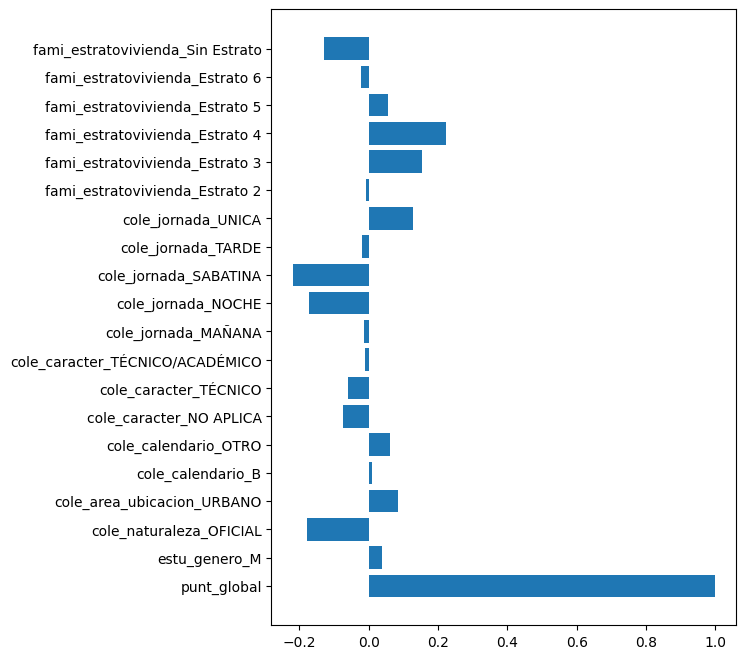

In [33]:
plt.figure(figsize=(6, 8))
plt.barh(y = data_num.columns, width=cor_variable_obj)

In [34]:
#Detección de irrelevantes = se buscan correlaciones con la variable objetivo muy bajas (0.0-0.05 ) ->ultima fila

data = data.drop('cole_calendario',axis=1)
data.head()

,cole_area_ubicacion,cole_caracter,cole_jornada,cole_naturaleza,estu_genero,fami_estratovivienda,punt_global
0,URBANO,ACADÉMICO,UNICA,NO OFICIAL,M,Estrato 4,275
1,URBANO,ACADÉMICO,UNICA,NO OFICIAL,M,Estrato 3,300
2,URBANO,TÉCNICO/ACADÉMICO,UNICA,OFICIAL,M,Estrato 1,329
3,URBANO,ACADÉMICO,MAÑANA,OFICIAL,F,Estrato 2,205
4,RURAL,TÉCNICO,COMPLETA,OFICIAL,M,Estrato 2,210


In [35]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 7 columns):
 #   Column                Non-Null Count  Dtype   
---  ------                --------------  -----   
 0   cole_area_ubicacion   1000 non-null   category
 1   cole_caracter         1000 non-null   object  
 2   cole_jornada          1000 non-null   category
 3   cole_naturaleza       1000 non-null   category
 4   estu_genero           1000 non-null   object  
 5   fami_estratovivienda  1000 non-null   object  
 6   punt_global           1000 non-null   int64   
dtypes: category(3), int64(1), object(3)
memory usage: 34.8+ KB


In [36]:
data.head()

,cole_area_ubicacion,cole_caracter,cole_jornada,cole_naturaleza,estu_genero,fami_estratovivienda,punt_global
0,URBANO,ACADÉMICO,UNICA,NO OFICIAL,M,Estrato 4,275
1,URBANO,ACADÉMICO,UNICA,NO OFICIAL,M,Estrato 3,300
2,URBANO,TÉCNICO/ACADÉMICO,UNICA,OFICIAL,M,Estrato 1,329
3,URBANO,ACADÉMICO,MAÑANA,OFICIAL,F,Estrato 2,205
4,RURAL,TÉCNICO,COMPLETA,OFICIAL,M,Estrato 2,210


In [37]:
#Creación de dummies a las variables categóricas

#Variables categóricas con 2 categorías -> Borramos una dummy
data = pd.get_dummies(data, columns=['cole_area_ubicacion','cole_naturaleza','estu_genero'], drop_first=True, dtype=int)

#Variables categóricas con más de 2 categorías -> No borramos
data = pd.get_dummies(data, columns=['fami_estratovivienda', 'cole_jornada', 'cole_caracter'], drop_first=False)
data.head()

,punt_global,cole_area_ubicacion_URBANO,cole_naturaleza_OFICIAL,estu_genero_M,fami_estratovivienda_Estrato 1,fami_estratovivienda_Estrato 2,fami_estratovivienda_Estrato 3,fami_estratovivienda_Estrato 4,fami_estratovivienda_Estrato 5,fami_estratovivienda_Estrato 6,...,cole_jornada_COMPLETA,cole_jornada_MAÑANA,cole_jornada_NOCHE,cole_jornada_SABATINA,cole_jornada_TARDE,cole_jornada_UNICA,cole_caracter_ACADÉMICO,cole_caracter_NO APLICA,cole_caracter_TÉCNICO,cole_caracter_TÉCNICO/ACADÉMICO
0,275,1,0,1,False,False,False,True,False,False,...,False,False,False,False,False,True,True,False,False,False
1,300,1,0,1,False,False,True,False,False,False,...,False,False,False,False,False,True,True,False,False,False
2,329,1,1,1,True,False,False,False,False,False,...,False,False,False,False,False,True,False,False,False,True
3,205,1,1,0,False,True,False,False,False,False,...,False,True,False,False,False,False,True,False,False,False
4,210,0,1,1,False,True,False,False,False,False,...,True,False,False,False,False,False,False,False,True,False


**Datos preparados**

In [38]:
data.to_excel('./datos_preparados.xlsx')

# **Modelos con división 70 - 30**

<Axes: >

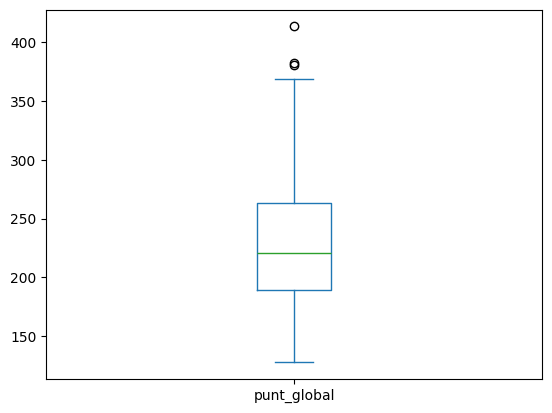

In [39]:
#División 70-30
from sklearn.model_selection import train_test_split
X = data.drop("punt_global", axis = 1) # Variables predictoras
Y = data['punt_global'] #Variable objetivo
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.3, stratify=None) #stratify none (porque es regresión)
Y_train.plot(kind='box')

<Axes: ylabel='Frequency'>

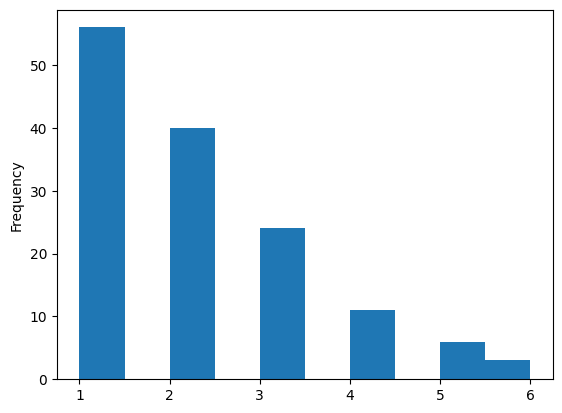

In [40]:
# Variable objetivo del 30% - hist
Y_test.value_counts().plot(kind='hist')

# Aprendizaje  70% y Evaluación 30%

In [41]:
#Dataframe para comparar los resultados
medidas= pd.DataFrame(index=['mse','rmse','mae','mape','max'])

# Arbol de Regresión
-No se normaliza

In [42]:
#Creación del modelo con el conjunto de entrenamiento
from sklearn.tree import DecisionTreeRegressor
model_Tree = DecisionTreeRegressor(criterion='squared_error', min_samples_leaf=2, max_depth=6)
model_Tree.fit(X_train, Y_train)#70% entrenamiento


DecisionTreeRegressor(max_depth=6, min_samples_leaf=2)

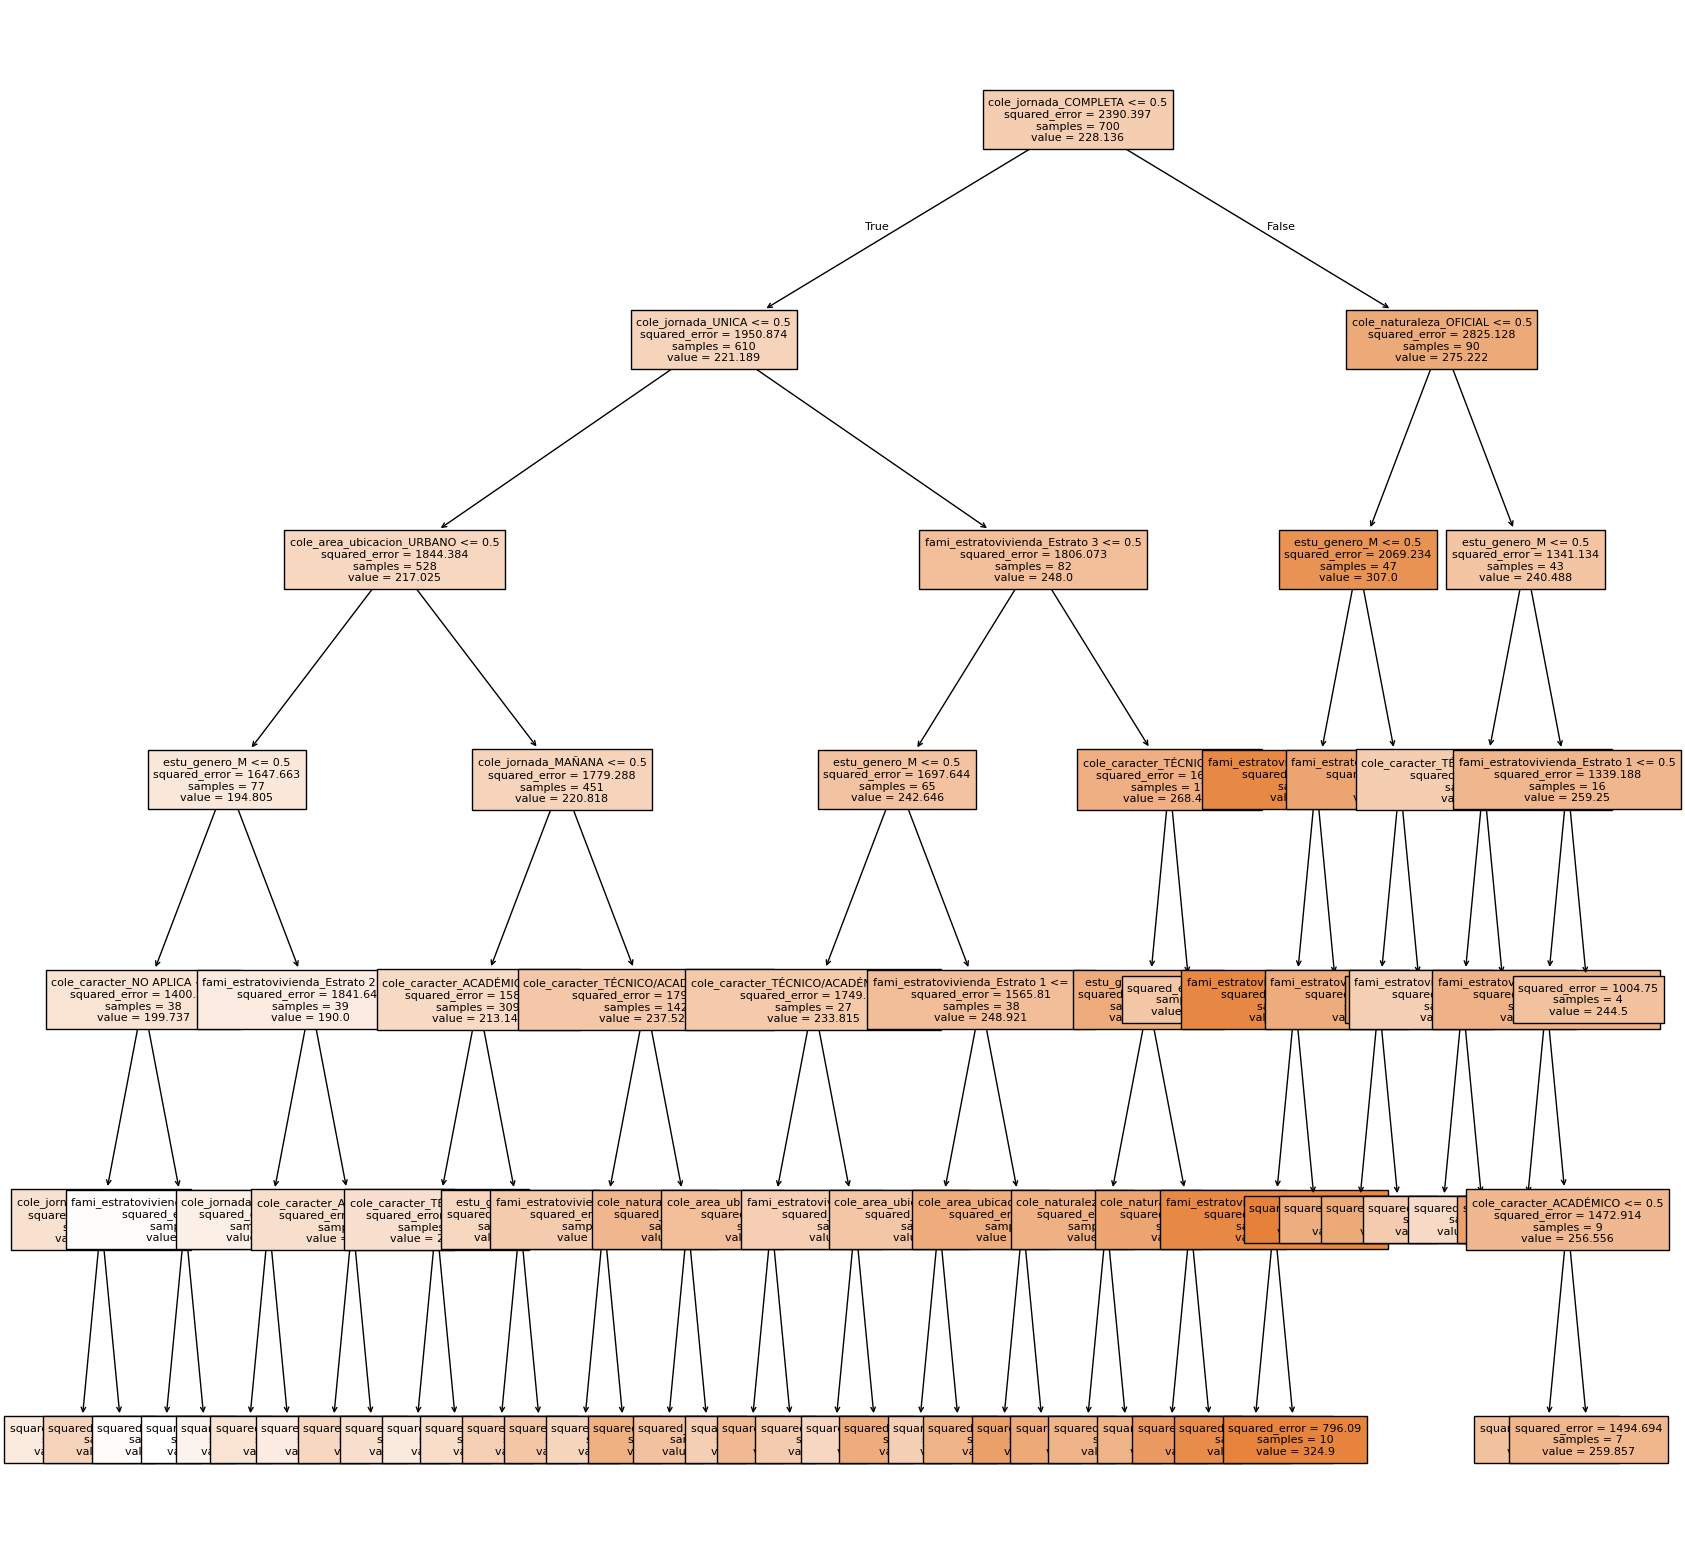

In [43]:
#Graficar el árbol
from sklearn.tree import plot_tree
nombres_variables=X_train.columns.values
plt.figure(figsize=(20,20))
plot_tree(model_Tree, feature_names=nombres_variables, filled=True,fontsize=8)
plt.show()

In [44]:
#Evaluación del árbol 30%
from sklearn import metrics
Y_pred = model_Tree.predict(X_test) #30%

#Medidas de evaluación en regresión
mse = metrics.mean_squared_error(Y_test,Y_pred) #No es intepretable
rmse = np.sqrt(mse) #Si es intepretable
mae= metrics.mean_absolute_error(Y_test,Y_pred) #Si es intepretable
mape=metrics.mean_absolute_percentage_error(Y_test,Y_pred) #Verificar si la objetivo es 0
max=metrics.max_error(Y_test,Y_pred)
medidas['Arbol']=[mse, rmse, mae, mape,max]
medidas

,Arbol
mse,1.895120e+03
rmse,4.353298e+01
mae,3.338393e+01
mape,4.368492e+15
max,2.910000e+02


/tmp/ipykernel_2972/2783684465.py:3: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "k--" (-> color='k'). The keyword argument will take precedence.
  plt.plot([Y_test.min(), Y_test.max()], [Y_test.min(), Y_test.max()],'k--', color = 'black', lw=2)


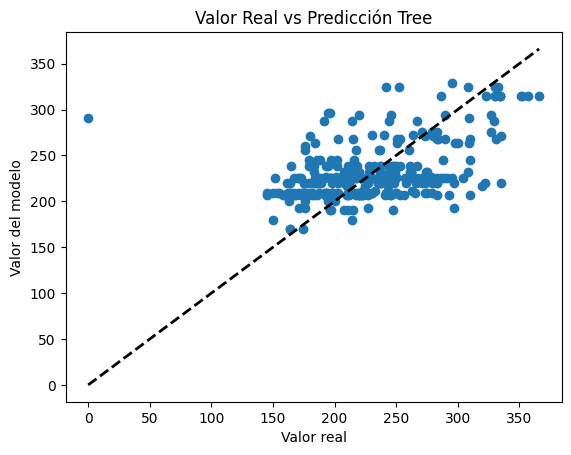

In [45]:
#Gráfica Valor Real vs Predicción
plt.scatter(Y_test, Y_pred)
plt.plot([Y_test.min(), Y_test.max()], [Y_test.min(), Y_test.max()],'k--', color = 'black', lw=2)
plt.xlabel('Valor real')
plt.ylabel('Valor del modelo')
plt.title('Valor Real vs Predicción Tree')
plt.show() # Mostrar la grafica luego de que ya se definio todos los elementos

# Random Forest para Regresión

In [46]:
#Random Forest
from sklearn.ensemble import RandomForestRegressor

model_rf= RandomForestRegressor(n_estimators=150,  max_samples=0.9, criterion='squared_error',
                              max_depth=9, min_samples_leaf=2)
model_rf.fit(X_train, Y_train) #70%

RandomForestRegressor(max_depth=9, max_samples=0.9, min_samples_leaf=2,
                      n_estimators=150)

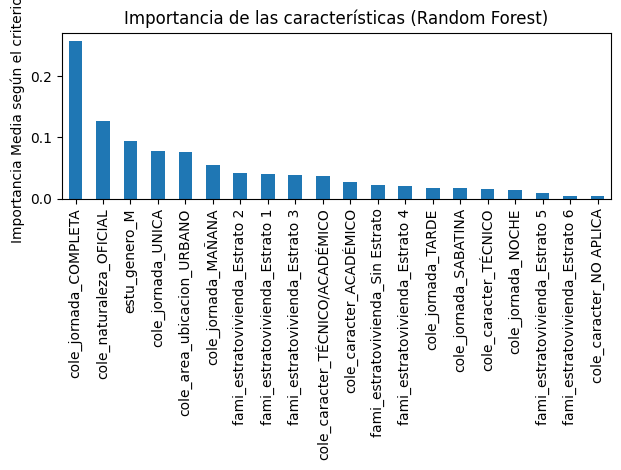

In [47]:
importances = model_rf.feature_importances_
feature_names = X_train.columns
forest_importances = pd.Series(importances, index=feature_names)

fig, ax = plt.subplots()
forest_importances.sort_values(ascending=False).plot.bar(ax=ax)
ax.set_title("Importancia de las características (Random Forest)")
ax.set_ylabel("Importancia Media según el criterion")
fig.tight_layout()
plt.show()

             Arbol            RF
mse   1.895120e+03  1.857664e+03
rmse  4.353298e+01  4.310062e+01
mae   3.338393e+01  3.297798e+01
mape  4.368492e+15  4.423859e+15
max   2.910000e+02  2.946882e+02


/tmp/ipykernel_2972/582828784.py:17: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "k--" (-> color='k'). The keyword argument will take precedence.
  plt.plot([Y_test.min(), Y_test.max()], [Y_test.min(), Y_test.max()],'k--', color = 'black', lw=2)


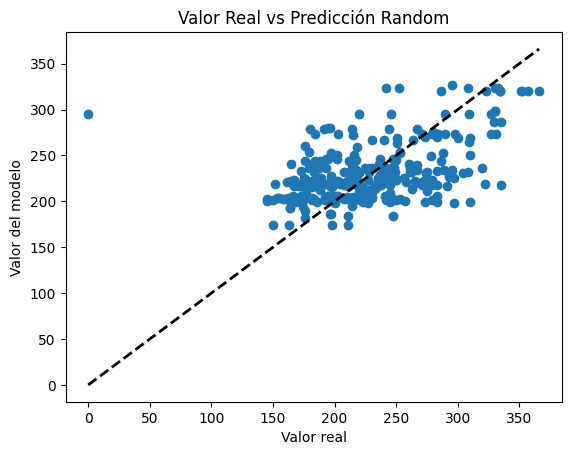

In [48]:
#Evaluación de Random
from sklearn import metrics

Y_pred = model_rf.predict(X_test) #30%

#Medidas de error
mse = metrics.mean_squared_error(Y_test,Y_pred)
rmse = np.sqrt(mse)
mae= metrics.mean_absolute_error(Y_test,Y_pred)
mape=metrics.mean_absolute_percentage_error(Y_test,Y_pred)
max=metrics.max_error(Y_test,Y_pred)
medidas['RF']=[mse, rmse, mae, mape,max]
print(medidas)

#Gráfica Valor Real vs Predicción
plt.scatter(Y_test, Y_pred)
plt.plot([Y_test.min(), Y_test.max()], [Y_test.min(), Y_test.max()],'k--', color = 'black', lw=2)
plt.xlabel('Valor real')
plt.ylabel('Valor del modelo')
plt.title('Valor Real vs Predicción Random')
plt.show()

# XGBOOST


             Arbol            RF       XGBoost
mse   1.895120e+03  1.857664e+03  2.126866e+03
rmse  4.353298e+01  4.310062e+01  4.611796e+01
mae   3.338393e+01  3.297798e+01  3.528113e+01
mape  4.368492e+15  4.423859e+15  4.368443e+15
max   2.910000e+02  2.946882e+02  2.909967e+02


/tmp/ipykernel_2972/1149815279.py:24: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "k--" (-> color='k'). The keyword argument will take precedence.
  plt.plot([Y_test.min(), Y_test.max()], [Y_test.min(), Y_test.max()], 'k--', color='black', lw=2)


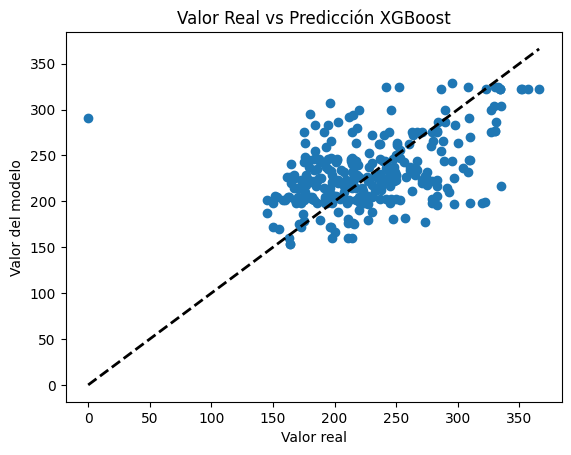

In [49]:
# XGBoost Regressor
from xgboost import XGBRegressor
from sklearn import metrics

# Model creation and training
model_xgb = XGBRegressor(n_estimators=300, max_depth=9, learning_rate=0.1, objective='reg:squarederror')
model_xgb.fit(X_train, Y_train)

# Evaluation of XGBoost
Y_pred = model_xgb.predict(X_test)

# Error measures
mse = metrics.mean_squared_error(Y_test, Y_pred)
rmse = np.sqrt(mse)
mae = metrics.mean_absolute_error(Y_test, Y_pred)
mape = metrics.mean_absolute_percentage_error(Y_test, Y_pred)
max_err = metrics.max_error(Y_test, Y_pred)

medidas['XGBoost'] = [mse, rmse, mae, mape, max_err]
print(medidas)

# Real vs Prediction Plot
plt.scatter(Y_test, Y_pred)
plt.plot([Y_test.min(), Y_test.max()], [Y_test.min(), Y_test.max()], 'k--', color='black', lw=2)
plt.xlabel('Valor real')
plt.ylabel('Valor del modelo')
plt.title('Valor Real vs Predicción XGBoost')
plt.show()

# KNN

No se normaliza porque todas las variables son categoricas

In [50]:
from sklearn.neighbors import  KNeighborsRegressor
model_Knn = KNeighborsRegressor(n_neighbors=1, metric='euclidean') #minkowski
model_Knn.fit(X_train, Y_train) #70%

KNeighborsRegressor(metric='euclidean', n_neighbors=1)

             Arbol            RF       XGBoost           Knn
mse   1.895120e+03  1.857664e+03  2.126866e+03  3.087873e+03
rmse  4.353298e+01  4.310062e+01  4.611796e+01  5.556864e+01
mae   3.338393e+01  3.297798e+01  3.528113e+01  4.144667e+01
mape  4.368492e+15  4.423859e+15  4.368443e+15  5.059044e+15
max   2.910000e+02  2.946882e+02  2.909967e+02  3.370000e+02


/tmp/ipykernel_2972/27550333.py:17: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "k--" (-> color='k'). The keyword argument will take precedence.
  plt.plot([Y_test.min(), Y_test.max()], [Y_test.min(), Y_test.max()],'k--', color = 'black', lw=2)


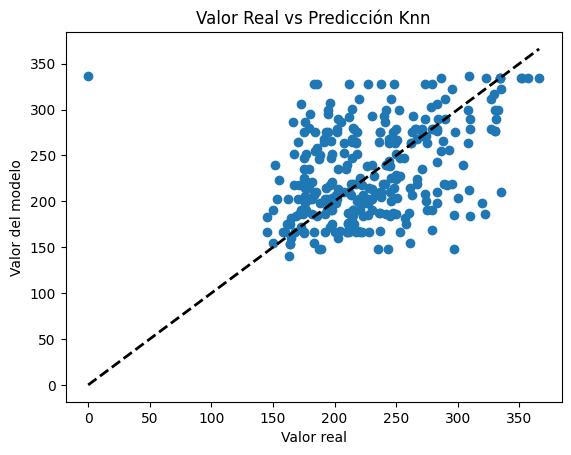

In [51]:
#Evaluación de KNN
from sklearn import metrics

Y_pred = model_Knn.predict(X_test) #30%

#Medidas de error
mse = metrics.mean_squared_error(Y_test,Y_pred)
rmse = np.sqrt(mse)
mae= metrics.mean_absolute_error(Y_test,Y_pred)
mape=metrics.mean_absolute_percentage_error(Y_test,Y_pred)
max=metrics.max_error(Y_test,Y_pred)
medidas['Knn']=[mse, rmse, mae, mape,max]
print(medidas)

#Gráfica Valor Real vs Predicción
plt.scatter(Y_test, Y_pred)
plt.plot([Y_test.min(), Y_test.max()], [Y_test.min(), Y_test.max()],'k--', color = 'black', lw=2)
plt.xlabel('Valor real')
plt.ylabel('Valor del modelo')
plt.title('Valor Real vs Predicción Knn')
plt.show()

# Red Neuronal para Regresión


In [52]:
from sklearn.neural_network import MLPRegressor

#Solo se configura capas ocultas, no se configura capa de entrada y de salida
#activation -> función activación de la oculta: sigmoid, logistic, linear, relu
#hidden_layer_sizes=5,7 -> dos capas ocultas con 5 neuronas y 7 neuronas
#learning_rate-> tamaño del paso constante o decreciente (constant, adaptive)
#learning_rate_init-> valor tasa de aprendizaje
#momentum-> valor momentum
#max_iter-> iteaciones
#random_state-> semilla para generacion numeros seudoaletorios

model_NN = MLPRegressor(activation="relu",hidden_layer_sizes=(16, 12, 8), learning_rate='constant',
                     learning_rate_init=0.03, momentum= 0.02, max_iter=500,  random_state=3)

model_NN.fit(X_train, Y_train)#70%

MLPRegressor(hidden_layer_sizes=(16, 12, 8), learning_rate_init=0.03,
             max_iter=500, momentum=0.02, random_state=3)

             Arbol            RF       XGBoost           Knn  \
mse   1.895120e+03  1.857664e+03  2.126866e+03  3.087873e+03   
rmse  4.353298e+01  4.310062e+01  4.611796e+01  5.556864e+01   
mae   3.338393e+01  3.297798e+01  3.528113e+01  4.144667e+01   
mape  4.368492e+15  4.423859e+15  4.368443e+15  5.059044e+15   
max   2.910000e+02  2.946882e+02  2.909967e+02  3.370000e+02   

                      NN  
mse   1877.8462883354068  
rmse           43.334124  
mae            33.820551  
mape  4207306694119177.5  
max           280.262926  


/tmp/ipykernel_2972/2455914236.py:17: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "k--" (-> color='k'). The keyword argument will take precedence.
  plt.plot([Y_test.min(), Y_test.max()], [Y_test.min(), Y_test.max()],'k--', color = 'black', lw=2)


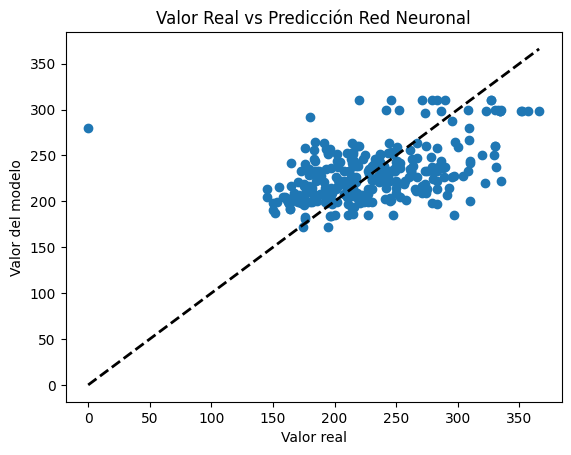

In [53]:
#Evaluación de NN
from sklearn import metrics

Y_pred = model_NN.predict(X_test) #30%

#Medidas de error
mse = metrics.mean_squared_error(Y_test,Y_pred)
rmse = np.sqrt(mse)
mae= metrics.mean_absolute_error(Y_test,Y_pred)
mape=metrics.mean_absolute_percentage_error(Y_test,Y_pred)
max=metrics.max_error(Y_test,Y_pred)
medidas['NN']=[format(mse), rmse, mae, mape,max]
print(medidas)

#Gráfica Valor Real vs Predicción
plt.scatter(Y_test, Y_pred)
plt.plot([Y_test.min(), Y_test.max()], [Y_test.min(), Y_test.max()],'k--', color = 'black', lw=2)
plt.xlabel('Valor real')
plt.ylabel('Valor del modelo')
plt.title('Valor Real vs Predicción Red Neuronal')
plt.show()

# SVM para Regresión - SVR

-Normalizar

In [54]:
#SVR
#Kernel='linear', 'poly', 'rbf', 'sigmoid', 'precomputed'

#SVM
from sklearn.svm import SVR

modelSVM = SVR(kernel='poly', C=9) #'linear', 'poly'->degree, 'rbf', 'sigmoid', 'precomputed'
modelSVM.fit(X_train, Y_train) #70%


SVR(C=9, kernel='poly')

             Arbol            RF       XGBoost           Knn  \
mse   1.895120e+03  1.857664e+03  2.126866e+03  3.087873e+03   
rmse  4.353298e+01  4.310062e+01  4.611796e+01  5.556864e+01   
mae   3.338393e+01  3.297798e+01  3.528113e+01  4.144667e+01   
mape  4.368492e+15  4.423859e+15  4.368443e+15  5.059044e+15   
max   2.910000e+02  2.946882e+02  2.909967e+02  3.370000e+02   

                      NN                 SVM  
mse   1877.8462883354068  1868.6900878388908  
rmse           43.334124           43.228348  
mae            33.820551           33.475981  
mape  4207306694119177.5  4142326270572283.5  
max           280.262926           275.93436  


/tmp/ipykernel_2972/1638901598.py:17: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "k--" (-> color='k'). The keyword argument will take precedence.
  plt.plot([Y_test.min(), Y_test.max()], [Y_test.min(), Y_test.max()],'k--', color = 'black', lw=2)


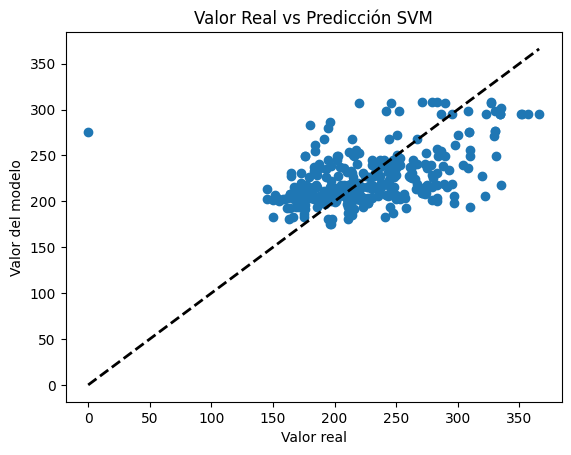

In [55]:
#Evaluación de SVM
from sklearn import metrics

Y_pred = modelSVM.predict(X_test) #30%

#Medidas de error
mse = metrics.mean_squared_error(Y_test,Y_pred)
rmse = np.sqrt(mse)
mae= metrics.mean_absolute_error(Y_test,Y_pred)
mape=metrics.mean_absolute_percentage_error(Y_test,Y_pred)
max=metrics.max_error(Y_test,Y_pred)
medidas['SVM']=[format(mse), rmse, mae, mape,max]
print(medidas)

#Gráfica Valor Real vs Predicción
plt.scatter(Y_test, Y_pred)
plt.plot([Y_test.min(), Y_test.max()], [Y_test.min(), Y_test.max()],'k--', color = 'black', lw=2)
plt.xlabel('Valor real')
plt.ylabel('Valor del modelo')
plt.title('Valor Real vs Predicción SVM')
plt.show()

# **Modelos creados con validación Cruzada**







Realiza una selección de factores, analizando las variables más relevantes para tu proyecto.

In [56]:
# Paso 1: Definir las candidatas

X = data.drop('punt_global', axis=1).astype(float)
Y = data['punt_global']
print(X.shape)

(1000, 20)


In [57]:
# Paso 2: Filtro por varianza
# Elimina columnas casi constantes (categorías con muy pocos casos).

from sklearn.feature_selection import VarianceThreshold
vt = VarianceThreshold(threshold=0.01)   # solo 1% de variación
vt.fit(X)
print("Descartadas por poca varianza:", list(X.columns[~vt.get_support()]))

Descartadas por poca varianza: []


In [58]:
#Paso 3: Correlación con la variable objetivo

corr_y = pd.concat([X, Y], axis=1).corr()['punt_global'].drop('punt_global')
corr_y = corr_y.reindex(corr_y.abs().sort_values(ascending=False).index)
corr_y.round(3)

,punt_global
cole_jornada_COMPLETA,0.373
fami_estratovivienda_Estrato 4,0.223
cole_jornada_SABATINA,-0.219
cole_naturaleza_OFICIAL,-0.179
cole_jornada_NOCHE,-0.173
fami_estratovivienda_Estrato 1,-0.172
fami_estratovivienda_Estrato 3,0.153
cole_jornada_UNICA,0.128
fami_estratovivienda_Sin Estrato,-0.128
cole_area_ubicacion_URBANO,0.084


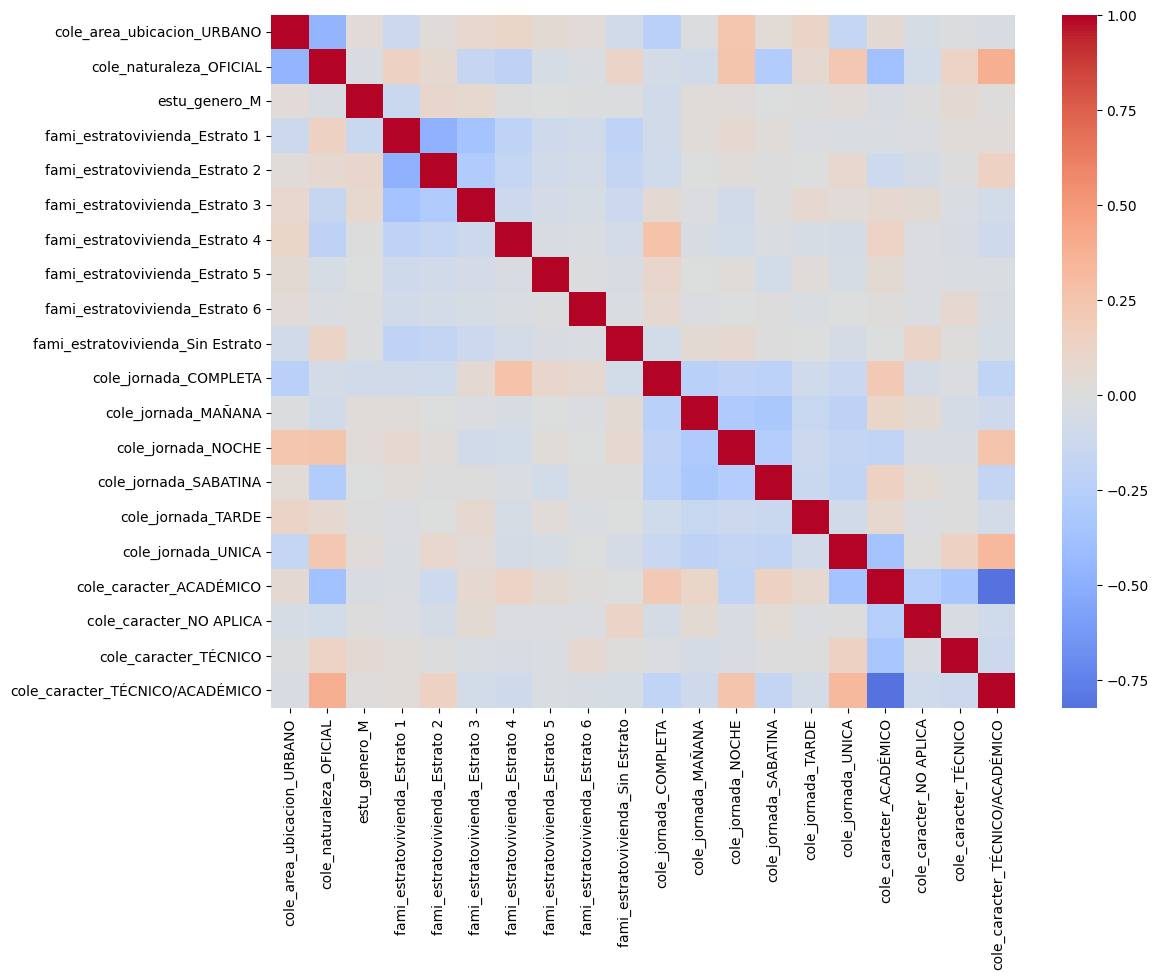

cole_caracter_ACADÉMICO  cole_caracter_TÉCNICO/ACADÉMICO   -0.822597
dtype: float64


In [59]:
# Paso 4: Multicolinealidad entre predictoras
# Si dos variables tienen |r| > 0.8 entre sí, quédate con la que más correlacione con Y.

import seaborn as sns, matplotlib.pyplot as plt
c = X.corr()
plt.figure(figsize=(12,9)); sns.heatmap(c, cmap='coolwarm', center=0); plt.show()

pares = c.where(np.triu(np.ones(c.shape), 1).astype(bool)).stack()
print(pares[pares.abs() > 0.8].sort_values())

In [60]:
# Paso 5: Importancia estadística (filtros)

from sklearn.feature_selection import f_regression, mutual_info_regression

ranking = pd.DataFrame(index=X.columns)
ranking['F'] = f_regression(X, Y)[0]                                 # relación lineal
ranking['info_mutua'] = mutual_info_regression(X, Y, random_state=42)  # relación no lineal

In [61]:
# Paso 6: Importancia con modelos
# Usa la importancia por permutación, que es más confiable que feature_importances_ con variables binarias.

from sklearn.ensemble import RandomForestRegressor
from sklearn.inspection import permutation_importance
from sklearn.model_selection import train_test_split

Xtr, Xte, ytr, yte = train_test_split(X, Y, test_size=0.3, random_state=42)
rf = RandomForestRegressor(n_estimators=200, min_samples_leaf=5, random_state=42).fit(Xtr, ytr)

ranking['imp_rf'] = rf.feature_importances_
perm = permutation_importance(rf, Xte, yte, n_repeats=20, random_state=42, scoring='neg_root_mean_squared_error')
ranking['imp_perm'] = perm.importances_mean

In [62]:
# Paso 7: Eliminación recursiva (RFECV)
# Este método elige el número óptimo de variables con validación cruzada.

from sklearn.feature_selection import RFECV
rfecv = RFECV(RandomForestRegressor(n_estimators=100, min_samples_leaf=5, random_state=42),
              step=1, cv=10, scoring='neg_root_mean_squared_error', n_jobs=-1)
rfecv.fit(X, Y)
print("Número óptimo de variables:", rfecv.n_features_)
print(list(X.columns[rfecv.support_]))

Número óptimo de variables: 20
['cole_area_ubicacion_URBANO', 'cole_naturaleza_OFICIAL', 'estu_genero_M', 'fami_estratovivienda_Estrato 1', 'fami_estratovivienda_Estrato 2', 'fami_estratovivienda_Estrato 3', 'fami_estratovivienda_Estrato 4', 'fami_estratovivienda_Estrato 5', 'fami_estratovivienda_Estrato 6', 'fami_estratovivienda_Sin Estrato', 'cole_jornada_COMPLETA', 'cole_jornada_MAÑANA', 'cole_jornada_NOCHE', 'cole_jornada_SABATINA', 'cole_jornada_TARDE', 'cole_jornada_UNICA', 'cole_caracter_ACADÉMICO', 'cole_caracter_NO APLICA', 'cole_caracter_TÉCNICO', 'cole_caracter_TÉCNICO/ACADÉMICO']


In [63]:
# Paso 8: Consolidar el ranking
# Combina todos los métodos y elige las variables que salen arriba en la mayoría.

ranking['corr_abs'] = corr_y.abs()
ranking['en_RFECV'] = rfecv.support_.astype(int)
posiciones = ranking.drop(columns='en_RFECV').rank(ascending=False)
ranking['promedio_pos'] = posiciones.mean(axis=1)
ranking.sort_values('promedio_pos').round(3).head(15)

,F,info_mutua,imp_rf,imp_perm,corr_abs,en_RFECV,promedio_pos
cole_jornada_COMPLETA,161.134,0.075,0.302,12.271,0.373,1,1.0
cole_naturaleza_OFICIAL,32.932,0.034,0.134,2.782,0.179,1,3.2
fami_estratovivienda_Estrato 4,51.991,0.039,0.010,0.444,0.223,1,6.2
cole_jornada_UNICA,16.744,0.009,0.085,2.169,0.128,1,6.6
cole_area_ubicacion_URBANO,7.091,0.029,0.071,1.353,0.084,1,7.0
cole_jornada_SABATINA,50.360,0.013,0.024,0.114,0.219,1,7.8
fami_estratovivienda_Estrato 1,30.375,0.006,0.061,0.586,0.172,1,7.8
cole_jornada_NOCHE,30.728,0.041,0.014,-0.048,0.173,1,9.2
fami_estratovivienda_Estrato 3,24.054,0.006,0.044,0.266,0.153,1,9.4
estu_genero_M,1.541,0.008,0.078,1.285,0.039,1,10.4


In [64]:
# Paso 9: Validar la selección con validación cruzada
# Compara el modelo con todas las variables contra el modelo con las seleccionadas. Usa el mismo cv y las mismas métricas de tus otros modelos.

from sklearn.model_selection import cross_validate
seleccion = list(ranking.sort_values('promedio_pos').index[:8])   # ajusta el número

modelo = RandomForestRegressor(n_estimators=200, min_samples_leaf=5, random_state=42)
scoring = ('neg_mean_absolute_error', 'neg_root_mean_squared_error', 'r2')
for nombre, cols in [('Todas', X.columns), ('Seleccionadas', seleccion)]:
    s = cross_validate(modelo, X[cols], Y, cv=10, scoring=scoring)
    print(nombre, len(cols), "variables | MAE:", round(-s['test_neg_mean_absolute_error'].mean(), 2),
          "| RMSE:", round(-s['test_neg_root_mean_squared_error'].mean(), 2),
          "| R2:", round(s['test_r2'].mean(), 3))

Todas 20 variables | MAE: 33.64 | RMSE: 42.05 | R2: 0.153
Seleccionadas 8 variables | MAE: 34.33 | RMSE: 42.79 | R2: 0.12


In [65]:
# Evaluación por variable, no por dummies
grupos = {'estrato': [c for c in X if c.startswith('fami_estrato')],
          'jornada': [c for c in X if c.startswith('cole_jornada')],
          'caracter': [c for c in X if c.startswith('cole_caracter')],
          'naturaleza': ['cole_naturaleza_OFICIAL'],
          'area': ['cole_area_ubicacion_URBANO'],
          'genero': ['estu_genero_M']}

base = cross_validate(modelo, X, Y, cv=10, scoring='neg_root_mean_squared_error')['test_score'].mean()
for g, cols in grupos.items():
    s = cross_validate(modelo, X.drop(columns=cols), Y, cv=10, scoring='neg_root_mean_squared_error')['test_score'].mean()
    print(f"{g:11s} | RMSE sin el grupo: {-s:.2f}  (cambio: {-s + base:+.2f})")

estrato     | RMSE sin el grupo: 42.07  (cambio: +0.03)
jornada     | RMSE sin el grupo: 48.48  (cambio: +6.44)
caracter    | RMSE sin el grupo: 42.35  (cambio: +0.31)
naturaleza  | RMSE sin el grupo: 42.22  (cambio: +0.17)
area        | RMSE sin el grupo: 42.05  (cambio: +0.00)
genero      | RMSE sin el grupo: 42.61  (cambio: +0.56)


Para la selección de factores se evaluó el aporte de cada grupo de variables eliminándolo del modelo y midiendo el cambio en el RMSE con validación cruzada (RMSE de referencia con todas las variables: 42.04). Ninguna eliminación redujo el error. La jornada del colegio es el factor más determinante: al quitarla, el RMSE sube de 42.04 a 48.48 (+6.44). Le siguen el género del estudiante (+0.56), el carácter del colegio (+0.31) y la naturaleza oficial o privada (+0.17), que aportan una mejora pequeña pero consistente. El estrato (+0.03) y el área de ubicación (0.00) tienen un aporte prácticamente nulo en presencia de las demás variables, probablemente porque su información ya está recogida por la jornada y la naturaleza del colegio. Además, una selección previa basada en las 8 variables más correlacionadas empeoró el desempeño (RMSE de 42.05 a 42.79 y R² de 0.153 a 0.120). Por estas razones, y porque el Random Forest tolera bien las variables de bajo aporte sin que le perjudiquen, se decidió conservar las seis variables o grupos (jornada, carácter, naturaleza, género, estrato y área) en los modelos finales, ya que eliminar cualquiera de ellas no mejora el desempeño y sí puede perder información.

In [66]:
#Validación Cruzada
from sklearn.model_selection import cross_validate

#Dataframe para comparar los modelos
comparacion_CV=pd.DataFrame()

#Medidas de evaluación
scoring=('neg_mean_absolute_error', 'neg_mean_squared_error','neg_root_mean_squared_error', 'neg_mean_absolute_percentage_error')

#Muestreo lineal
cv=10

In [67]:
objetivo='punt_global'

#Se separa variables predictoras y objetivo
X = data.drop(objetivo, axis = 1)
Y = data[objetivo]
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 20 columns):
 #   Column                            Non-Null Count  Dtype
---  ------                            --------------  -----
 0   cole_area_ubicacion_URBANO        1000 non-null   int64
 1   cole_naturaleza_OFICIAL           1000 non-null   int64
 2   estu_genero_M                     1000 non-null   int64
 3   fami_estratovivienda_Estrato 1    1000 non-null   bool 
 4   fami_estratovivienda_Estrato 2    1000 non-null   bool 
 5   fami_estratovivienda_Estrato 3    1000 non-null   bool 
 6   fami_estratovivienda_Estrato 4    1000 non-null   bool 
 7   fami_estratovivienda_Estrato 5    1000 non-null   bool 
 8   fami_estratovivienda_Estrato 6    1000 non-null   bool 
 9   fami_estratovivienda_Sin Estrato  1000 non-null   bool 
 10  cole_jornada_COMPLETA             1000 non-null   bool 
 11  cole_jornada_MAÑANA               1000 non-null   bool 
 12  cole_jornada_NOCHE                1

# TREE

In [68]:
#Tree
from sklearn import tree
modelTree = tree.DecisionTreeRegressor(criterion='squared_error', min_samples_leaf=6,
                                       max_depth=10)


scores = cross_validate(modelTree, X, Y, cv=cv, scoring=scoring, return_train_score=True, return_estimator=False)
scores=pd.DataFrame(scores) #Se almacenan los resultados en un dataframe
scores

,fit_time,score_time,test_neg_mean_absolute_error,train_neg_mean_absolute_error,test_neg_mean_squared_error,train_neg_mean_squared_error,test_neg_root_mean_squared_error,train_neg_root_mean_squared_error,test_neg_mean_absolute_percentage_error,train_neg_mean_absolute_percentage_error
0,0.003515,0.002816,-34.430567,-30.167550,-1790.961671,-1435.099587,-42.319755,-37.882708,-1.341350e-01,-1.184128e+15
1,0.002950,0.002794,-29.962439,-30.286257,-1392.232109,-1438.301690,-37.312627,-37.924948,-1.341079e-01,-1.176655e+15
2,0.002864,0.002754,-34.466856,-29.772392,-1857.778256,-1407.849322,-43.101952,-37.521318,-1.420166e-01,-1.176655e+15
3,0.002852,0.002694,-39.088646,-29.069852,-2952.847899,-1315.174891,-54.340113,-36.265340,-1.372097e+16,-1.314513e-01
4,0.002648,0.002558,-32.120091,-30.287943,-1725.486113,-1430.668777,-41.538971,-37.824182,-1.488770e-01,-1.115058e+15
5,0.002586,0.002881,-37.316809,-29.719420,-2050.561999,-1404.496064,-45.283132,-37.476607,-1.753181e-01,-1.176655e+15
6,0.002926,0.002956,-41.673476,-29.733724,-2272.477810,-1430.139701,-47.670513,-37.817188,-2.128530e-01,-1.339960e+15
7,0.003200,0.003219,-35.019264,-29.511899,-1742.917262,-1401.345938,-41.748261,-37.434555,-1.587497e-01,-1.139244e+15
8,0.003368,0.003309,-33.946737,-29.807909,-1732.307671,-1423.354396,-41.621000,-37.727369,-1.657495e-01,-1.176655e+15
9,0.002944,0.002595,-27.708178,-30.407620,-1251.022792,-1468.515908,-35.369801,-38.321220,-1.211721e-01,-1.176655e+15


In [69]:
# Promedios para verificar overfitting comparando medidas en train y test
scores.mean().to_frame('promedio').style.format('{:.4f}')

#Cuidado overfitting, más de 5 puntos de diferencia

,promedio
fit_time,0.0030
score_time,0.0029
test_neg_mean_absolute_error,-34.5733
train_neg_mean_absolute_error,-29.8765
test_neg_mean_squared_error,-1876.8594
train_neg_mean_squared_error,-1415.4946
test_neg_root_mean_squared_error,-43.0306
train_neg_root_mean_squared_error,-37.6195
test_neg_mean_absolute_percentage_error,-1372096686472211.2500
train_neg_mean_absolute_percentage_error,-1066166376720063.3750


In [70]:
#Se almacena en el df la medida a comparar
comparacion_CV['Tree']=scores['test_neg_mean_absolute_error']
comparacion_CV

,Tree
0,-34.430567
1,-29.962439
2,-34.466856
3,-39.088646
4,-32.120091
5,-37.316809
6,-41.673476
7,-35.019264
8,-33.946737
9,-27.708178


#Informe
# Modelo: Árbol de decisión para regresión (profundidad 10)

## 1. Configuración
- **Técnica:** `DecisionTreeRegressor`
- **Hiperparámetros:** `criterion='squared_error'`, `min_samples_leaf=6`, `max_depth=10`
- **Validación:** validación cruzada de 10 folds

## 2. Resultados (promedio de los 10 folds)

| Métrica | Train | Test | Diferencia |
|---|---|---|---|
| MAE | 29.88 | 34.58 | 4.71 |
| RMSE | 37.62 | 43.03 | 5.41 |
| MSE | 1415.49 | 1877.13 | 461.64 |
| MAPE | 1.07 × 10¹⁵ | 1.37 × 10¹⁵ | 3.06 × 10¹⁴ |
| R² (aprox.) | ~0.42 | ~0.22 | ~0.19 |

> El R² se calculó con el MSE y la varianza de `Y` (49.2² ≈ 2423).
> **Nota sobre el MAPE:** el valor es extremadamente alto porque `punt_global` contiene observaciones iguales a 0. Como el MAPE divide el error entre el valor real, esas filas generan errores enormes que dominan el promedio. Por eso la métrica no es interpretable en este conjunto de datos y no se usa para evaluar el sobreajuste.

## 3. Evaluación
- **Capacidad predictiva:** el modelo se equivoca en promedio ~35 puntos (MAE) en estudiantes nuevos y explica cerca del 22% de la varianza.
- **Overfitting:** la brecha en MAE (4.71) queda justo debajo del umbral.
- **Underfitting:** el error en train sigue siendo alto (R² ≈ 0.42), por lo que el modelo tampoco captura bien toda la variabilidad del puntaje. Las variables disponibles explican una parte limitada del desempeño.

## 4. Conclusión
El árbol presenta un sobreajuste moderado, con un error de prueba mayor al de entrenamiento, y una calidad predictiva **baja** (R² cercano a 0.22).

# **Random Forest**

In [71]:
#Random forest
from sklearn import ensemble
modelRf = ensemble.RandomForestRegressor(n_estimators=200, max_samples=0.9, criterion='squared_error', min_samples_leaf=3, max_depth=None)


scores = cross_validate(modelRf, X, Y, cv=cv, scoring=scoring, return_train_score=True, return_estimator=False)
scores=pd.DataFrame(scores) #Se almacenan los resultados en un dataframe
scores

,fit_time,score_time,test_neg_mean_absolute_error,train_neg_mean_absolute_error,test_neg_mean_squared_error,train_neg_mean_squared_error,test_neg_root_mean_squared_error,train_neg_root_mean_squared_error,test_neg_mean_absolute_percentage_error,train_neg_mean_absolute_percentage_error
0,0.300915,0.016549,-34.373300,-29.352849,-1768.550473,-1358.647307,-42.054137,-36.859833,-1.363436e-01,-1.124319e+15
1,0.362895,0.021542,-29.565815,-29.658552,-1383.030718,-1382.213119,-37.189121,-37.178127,-1.323104e-01,-1.208437e+15
2,0.431709,0.022060,-33.246923,-29.074201,-1734.907796,-1355.809907,-41.652224,-36.821324,-1.376206e-01,-1.215031e+15
3,0.425990,0.028694,-37.991515,-28.743898,-2791.420594,-1272.217145,-52.833896,-35.668153,-1.366213e+16,-1.302837e-01
4,0.417778,0.017136,-29.863364,-29.438618,-1582.878520,-1368.330756,-39.785406,-36.990955,-1.404661e-01,-1.281960e+15
5,0.273444,0.018900,-37.466144,-28.814741,-2085.268520,-1328.437620,-45.664740,-36.447738,-1.761831e-01,-1.282439e+15
6,0.274801,0.017324,-39.045067,-29.076195,-2051.292240,-1358.588893,-45.291194,-36.859041,-1.991843e-01,-1.276279e+15
7,0.289076,0.017891,-35.899606,-28.779013,-1814.734070,-1339.774926,-42.599696,-36.602936,-1.618222e-01,-1.227931e+15
8,0.280377,0.018024,-34.457095,-28.990037,-1756.268157,-1353.432572,-41.907853,-36.789028,-1.676611e-01,-1.209690e+15
9,0.278670,0.017700,-27.225620,-29.719099,-1215.019997,-1403.673668,-34.857137,-37.465633,-1.204765e-01,-1.263357e+15


In [72]:
# Promedios para verificar overfitting comparando medidas en train y test
scores.mean().to_frame('promedio').style.format('{:.4f}')#Cuidado overfitting, más de 5 puntos de diferencia

,promedio
fit_time,0.3336
score_time,0.0196
test_neg_mean_absolute_error,-33.9134
train_neg_mean_absolute_error,-29.1647
test_neg_mean_squared_error,-1818.3371
train_neg_mean_squared_error,-1352.1126
test_neg_root_mean_squared_error,-42.3835
train_neg_root_mean_squared_error,-36.7683
test_neg_mean_absolute_percentage_error,-1366213140307451.2500
train_neg_mean_absolute_percentage_error,-1108944241343519.6250


In [73]:
#Se almacena en el df la medida a comparar
comparacion_CV['RF']=scores['test_neg_mean_absolute_error']
comparacion_CV

,Tree,RF
0,-34.430567,-34.373300
1,-29.962439,-29.565815
2,-34.466856,-33.246923
3,-39.088646,-37.991515
4,-32.120091,-29.863364
5,-37.316809,-37.466144
6,-41.673476,-39.045067
7,-35.019264,-35.899606
8,-33.946737,-34.457095
9,-27.708178,-27.225620


# Informe

## 1. Configuración
- **Técnica:** `RandomForestRegressor`
- **Hiperparámetros:** `n_estimators=200`, `max_samples=0.9`, `criterion='squared_error'`, `min_samples_leaf=3`, `max_depth=None`
- **Validación:** validación cruzada de 10 folds

## 2. Resultados (promedio de los 10 folds)

| Métrica | Train | Test | Diferencia |
|---|---|---|---|
| MAE | 29.14 | 33.90 | 4.76 |
| RMSE | 36.76 | 42.37 | 5.61 |
| MSE | 1351.57 | 1818.52 | 466.95 |
| MAPE | 1.11 × 10¹⁵ | 1.37 × 10¹⁵ | 2.68 × 10¹⁴ |
| R² (aprox.) | ~0.44 | ~0.25 | ~0.19 |


> **Nota sobre el MAPE:** el valor es extremadamente alto porque `punt_global` contiene observaciones iguales a 0. Como el MAPE divide el error entre el valor real, esas filas generan errores enormes que dominan el promedio. Por eso la métrica no es interpretable en este conjunto de datos y no se usa para evaluar el sobreajuste.


## 3. Evaluación
- **Capacidad predictiva:** el modelo se equivoca en promedio ~34 puntos (MAE) en estudiantes nuevos y explica cerca del 25% de la varianza.
- **Overfitting:** la brecha en MAE (4.76) queda justo debajo del umbral. El error de test es ~16% mayor que el de train. Hay un **sobreajuste moderado**: aunque el promedio de muchos árboles reduce la varianza, con `max_depth=None` cada árbol puede crecer hasta ajustarse a particularidades de los datos de entrenamiento, y `min_samples_leaf=3` limita poco ese ajuste.
- **Underfitting:** el error en train sigue siendo alto (R² ≈ 0.44), lo que indica que el modelo no captura toda la variabilidad del puntaje incluso en los datos que ya conoce. Las variables disponibles explican una parte limitada del desempeño.

## 4. Conclusión
El Random Forest presenta un sobreajuste moderado y una calidad predictiva **baja** (R² cercano a 0.25).

# **XGBOOST**

In [74]:
#XGBoost
from xgboost import XGBRegressor
model_xgb = XGBRegressor(n_estimators=100, max_depth=None, learning_rate=0.03,
                         objective='reg:squarederror', random_state=3)


scores = cross_validate(model_xgb, X, Y, cv=cv, scoring=scoring, return_train_score=True, return_estimator=False)
scores=pd.DataFrame(scores) #Se almacenan los resultados en un dataframe

scores

,fit_time,score_time,test_neg_mean_absolute_error,train_neg_mean_absolute_error,test_neg_mean_squared_error,train_neg_mean_squared_error,test_neg_root_mean_squared_error,train_neg_root_mean_squared_error,test_neg_mean_absolute_percentage_error,train_neg_mean_absolute_percentage_error
0,0.042112,0.010327,-37.252205,-29.669762,-2149.700195,-1382.403809,-46.364861,-37.180691,-1.464532e-01,-8.474596e+14
1,0.054499,0.006370,-28.865599,-29.942921,-1356.513428,-1412.545410,-36.830875,-37.583843,-1.279681e-01,-1.116812e+15
2,0.038973,0.006258,-33.641685,-29.466949,-1752.061890,-1387.600220,-41.857639,-37.250507,-1.399758e-01,-1.116954e+15
3,0.040071,0.007761,-38.910919,-29.097229,-2839.466553,-1307.999390,-53.286644,-36.166275,-1.326279e+16,-1.317786e-01
4,0.040202,0.007035,-31.491972,-29.650679,-1723.868408,-1372.012085,-41.519493,-37.040680,-1.465665e-01,-9.889291e+14
5,0.038705,0.006347,-36.400864,-29.196386,-1962.670898,-1353.048340,-44.302040,-36.783806,-1.720397e-01,-1.117589e+15
6,0.039230,0.006291,-38.812988,-29.272125,-2011.937134,-1369.759766,-44.854622,-37.010265,-1.984070e-01,-1.120197e+15
7,0.037980,0.006509,-34.232048,-29.289797,-1656.804810,-1377.316406,-40.703869,-37.112213,-1.543433e-01,-1.117150e+15
8,0.050973,0.006332,-34.363422,-29.568596,-1748.672485,-1392.046631,-41.817131,-37.310143,-1.683426e-01,-1.120001e+15
9,0.037819,0.006191,-27.819809,-30.153168,-1206.883667,-1445.360962,-34.740231,-38.017902,-1.243723e-01,-1.119103e+15


In [75]:
# Promedios para verificar overfitting comparando medidas en train y test
scores.mean().to_frame('promedio').style.format('{:.4f}')#Cuidado overfitting, más de 5 puntos de diferencia

,promedio
fit_time,0.0421
score_time,0.0069
test_neg_mean_absolute_error,-34.1792
train_neg_mean_absolute_error,-29.5308
test_neg_mean_squared_error,-1840.8579
train_neg_mean_squared_error,-1380.0093
test_neg_root_mean_squared_error,-42.6277
train_neg_root_mean_squared_error,-37.1456
test_neg_mean_absolute_percentage_error,-1326279458553856.0000
train_neg_mean_absolute_percentage_error,-966419503330099.2500


In [76]:
#Se almacena en el df la medida a comparar
comparacion_CV['XGBoost']=scores['test_neg_mean_absolute_error']
comparacion_CV

,Tree,RF,XGBoost
0,-34.430567,-34.373300,-37.252205
1,-29.962439,-29.565815,-28.865599
2,-34.466856,-33.246923,-33.641685
3,-39.088646,-37.991515,-38.910919
4,-32.120091,-29.863364,-31.491972
5,-37.316809,-37.466144,-36.400864
6,-41.673476,-39.045067,-38.812988
7,-35.019264,-35.899606,-34.232048
8,-33.946737,-34.457095,-34.363422
9,-27.708178,-27.225620,-27.819809


# Informe

## 1. Configuración
- **Técnica:** `XGBRegressor` (boosting de árboles: cada árbol corrige los errores del anterior)
- **Hiperparámetros:** `n_estimators=100`, `max_depth=None`, `learning_rate=0.03`, `objective='reg:squarederror'`, `random_state=3`
- **Validación:** validación cruzada de 10 folds

## 2. Resultados (promedio de los 10 folds)

| Métrica | Train | Test | Diferencia |
|---|---|---|---|
| MAE | 29.53 | 34.18 | 4.65 |
| RMSE | 37.15 | 42.63 | 5.48 |
| MSE | 1380.01 | 1840.86 | 460.85 |
| MAPE | 9.66 × 10¹⁴ | 1.33 × 10¹⁵ | 3.60 × 10¹⁴ |
| R² (aprox.) | ~0.43 | ~0.24 | ~0.19 |


> **Nota sobre el MAPE:** el valor es extremadamente alto porque `punt_global` contiene observaciones iguales a 0. Como el MAPE divide el error entre el valor real, esas filas generan errores enormes que dominan el promedio. Por eso la métrica no es interpretable en este conjunto de datos y no se usa para evaluar el sobreajuste.


## 3. Evaluación
- **Capacidad predictiva:** el modelo se equivoca en promedio ~34 puntos (MAE) en estudiantes nuevos y explica cerca del 24% de la varianza.
- **Overfitting:** la brecha en el MAE (4.65) queda justo debajo del umbral. El error de test es ~15% mayor que el de train. Hay un **sobreajuste moderado**: con 100 árboles, el boosting empieza a ajustar particularidades de los datos de entrenamiento que no se generalizan a datos nuevos.
- **Underfitting:** el error en train sigue siendo alto (R² ≈ 0.43), lo que indica que el modelo no captura toda la variabilidad del puntaje ni siquiera en los datos con los que aprende. Las variables disponibles aportan información limitada sobre el desempeño.

## 4. Conclusión
El XGBoost presenta un sobreajuste moderado y una calidad predictiva **baja** (R² cercano a 0.24). Aumentar el número de árboles lo ajustaría aún más a los datos de entrenamiento sin mejorar el error de prueba. Reducir la profundidad de los árboles o agregar regularización (por ejemplo, `subsample` o `min_child_weight`) podría disminuir la brecha entre train y test, pero el límite principal está en la información que aportan las variables predictoras.

# KNN

In [77]:
#Método Perezoso
from sklearn.neighbors import KNeighborsRegressor
model_knn = KNeighborsRegressor(n_neighbors=9, metric='euclidean')


scores = cross_validate(model_knn, X, Y, cv=cv, scoring=scoring, return_train_score=True, return_estimator=False)
scores=pd.DataFrame(scores) #Se almacenan los resultados en un dataframe

scores



,fit_time,score_time,test_neg_mean_absolute_error,train_neg_mean_absolute_error,test_neg_mean_squared_error,train_neg_mean_squared_error,test_neg_root_mean_squared_error,train_neg_root_mean_squared_error,test_neg_mean_absolute_percentage_error,train_neg_mean_absolute_percentage_error
0,0.005431,0.005154,-34.813333,-31.516790,-1907.190370,-1536.535857,-43.671391,-39.198672,-1.334359e-01,-1.144248e+15
1,0.002386,0.004903,-31.810000,-31.634198,-1543.375679,-1542.952936,-39.285820,-39.280440,-1.424462e-01,-1.167044e+15
2,0.002270,0.004891,-32.907778,-31.208272,-1625.325062,-1530.713567,-40.315320,-39.124335,-1.392950e-01,-1.167044e+15
3,0.002350,0.004940,-38.386667,-30.487654,-2723.773580,-1427.296872,-52.189784,-37.779583,-1.172938e+16,-1.378135e-01
4,0.002239,0.004965,-31.507778,-31.182716,-1636.008272,-1512.640027,-40.447599,-38.892673,-1.472480e-01,-1.131460e+15
5,0.002198,0.004822,-38.828889,-30.448642,-2173.505185,-1464.499698,-46.620866,-38.268782,-1.831886e-01,-1.083088e+15
6,0.002436,0.004959,-38.411111,-30.800741,-2052.781481,-1508.606063,-45.307632,-38.840778,-1.956861e-01,-1.252668e+15
7,0.002450,0.004915,-35.923333,-30.621481,-1760.328765,-1482.793937,-41.956272,-38.507063,-1.619116e-01,-1.230428e+15
8,0.002202,0.005669,-35.537778,-31.118519,-1852.247901,-1510.399369,-43.037750,-38.863857,-1.740626e-01,-1.132016e+15
9,0.002202,0.004821,-30.770000,-32.160494,-1431.689259,-1593.352620,-37.837670,-39.916821,-1.389429e-01,-1.233208e+15


In [78]:
# Promedios para verificar overfitting comparando medida de train y test
scores.mean().to_frame('promedio').style.format('{:.4f}')

# Muy sospechoso

,promedio
fit_time,0.0026
score_time,0.0050
test_neg_mean_absolute_error,-34.8897
train_neg_mean_absolute_error,-31.1180
test_neg_mean_squared_error,-1870.6226
train_neg_mean_squared_error,-1510.9791
test_neg_root_mean_squared_error,-43.0670
train_neg_root_mean_squared_error,-38.8673
test_neg_mean_absolute_percentage_error,-1172937502950716.0000
train_neg_mean_absolute_percentage_error,-1054120312781694.6250


In [79]:
#Se almacena en el df la medida a comparar
comparacion_CV['Knn']=scores['test_neg_mean_absolute_error']
print(comparacion_CV)

        Tree         RF    XGBoost        Knn
0 -34.430567 -34.373300 -37.252205 -34.813333
1 -29.962439 -29.565815 -28.865599 -31.810000
2 -34.466856 -33.246923 -33.641685 -32.907778
3 -39.088646 -37.991515 -38.910919 -38.386667
4 -32.120091 -29.863364 -31.491972 -31.507778
5 -37.316809 -37.466144 -36.400864 -38.828889
6 -41.673476 -39.045067 -38.812988 -38.411111
7 -35.019264 -35.899606 -34.232048 -35.923333
8 -33.946737 -34.457095 -34.363422 -35.537778
9 -27.708178 -27.225620 -27.819809 -30.770000


# Informe

## 1. Configuración
- **Técnica:** `KNeighborsRegressor` (método perezoso: no construye un modelo explícito, guarda los datos de entrenamiento y predice con los vecinos más cercanos)
- **Hiperparámetros:** `n_neighbors=9`, `metric='euclidean'`
- **Validación:** validación cruzada de 10 folds

## 2. Resultados (promedio de los 10 folds)

| Métrica | Train | Test | Diferencia |
|---|---|---|---|
| MAE | 31.12 | 34.89 | 3.77 |
| RMSE | 38.87 | 43.07 | 4.20 |
| MSE | 1510.98 | 1870.62 | 359.64 |
| MAPE | 1.05 × 10¹⁵ | 1.17 × 10¹⁵ | 1.19 × 10¹⁴ |
| R² (aprox.) | ~0.38 | ~0.23 | ~0.15 |

> **Nota sobre el MAPE:** el valor es extremadamente alto porque `punt_global` contiene observaciones iguales a 0. Como el MAPE divide el error entre el valor real, esas filas generan errores enormes que dominan el promedio. Por eso la métrica no es interpretable en este conjunto de datos y no se usa para evaluar el sobreajuste.

## 3. Evaluación
- **Capacidad predictiva:** el modelo se equivoca en promedio ~35 puntos (MAE) en estudiantes nuevos y explica cerca del 23% de la varianza.
- **Overfitting:** las brechas entre train y test son de 3.77 en MAE y 4.20 en RMSE, ambas por debajo del umbral de 5 puntos. El error de test es ~11% a 12% mayor que el de train, por lo que el sobreajuste es **leve**. Usar 9 vecinos suaviza las predicciones, ya que cada una se obtiene promediando varias observaciones y no depende de un único caso.
- **Underfitting:** el error en train es alto (R² ≈ 0.38). El modelo no logra explicar bien ni los datos de entrenamiento, lo que indica que las variables disponibles aportan información limitada sobre el puntaje.

## 4. Conclusión
El KNN muestra un sobreajuste leve y una calidad predictiva **baja** (R² cercano a 0.23). La brecha entre train y test es pequeña, pero los errores altos en ambos conjuntos evidencian subajuste. Variar el número de vecinos podría modificar ligeramente el balance entre ambos, pero el límite principal está en la información que aportan las variables predictoras.

# NN

In [80]:
#Red neuronal
from sklearn.neural_network import MLPRegressor
model_rn = MLPRegressor(activation="relu",hidden_layer_sizes=(16, 12, 8), learning_rate='constant',
                     learning_rate_init=0.03, momentum= 0.02, max_iter=500,  random_state=3)


scores = cross_validate(model_rn, X, Y, cv=cv, scoring=scoring, return_train_score=True, return_estimator=False)
scores=pd.DataFrame(scores) #Se almacenan los resultados en un dataframe

scores



,fit_time,score_time,test_neg_mean_absolute_error,train_neg_mean_absolute_error,test_neg_mean_squared_error,train_neg_mean_squared_error,test_neg_root_mean_squared_error,train_neg_root_mean_squared_error,test_neg_mean_absolute_percentage_error,train_neg_mean_absolute_percentage_error
0,0.299172,0.003094,-40.271195,-32.584379,-2372.864165,-1629.032734,-48.712054,-40.361278,-1.585893e-01,-1.366265e+15
1,0.330666,0.003285,-30.462753,-32.667039,-1407.379522,-1656.204733,-37.515057,-40.696495,-1.353241e-01,-1.403390e+15
2,0.309242,0.003307,-33.756641,-31.840631,-1735.041388,-1618.388206,-41.653828,-40.229196,-1.399085e-01,-1.436499e+15
3,0.282325,0.005042,-38.947202,-31.613054,-2785.834942,-1520.257080,-52.781009,-38.990474,-1.330216e+16,-1.441554e-01
4,0.252146,0.003211,-30.681596,-32.318649,-1574.605196,-1631.032933,-39.681295,-40.386049,-1.414027e-01,-1.431411e+15
5,0.224741,0.003290,-35.631359,-31.964502,-1885.195053,-1591.794691,-43.418833,-39.897302,-1.686324e-01,-1.406589e+15
6,0.220118,0.002995,-38.191565,-31.762406,-2016.606567,-1588.109633,-44.906643,-39.851093,-1.946089e-01,-1.384824e+15
7,0.223779,0.003566,-33.879375,-31.999733,-1632.470870,-1623.431153,-40.403847,-40.291825,-1.499920e-01,-1.413018e+15
8,0.199014,0.003243,-34.781578,-32.042685,-1814.320857,-1617.333716,-42.594845,-40.216088,-1.685181e-01,-1.415049e+15
9,0.253599,0.003374,-27.390207,-32.915316,-1221.057677,-1671.864783,-34.943636,-40.888443,-1.209536e-01,-1.391144e+15


In [81]:
# Promedios para verificar overfitting comparando medida de train y test
scores.mean().to_frame('promedio').style.format('{:.4f}')

,promedio
fit_time,0.2595
score_time,0.0034
test_neg_mean_absolute_error,-34.3993
train_neg_mean_absolute_error,-32.1708
test_neg_mean_squared_error,-1844.5376
train_neg_mean_squared_error,-1614.7450
test_neg_root_mean_squared_error,-42.6611
train_neg_root_mean_squared_error,-40.1808
test_neg_mean_absolute_percentage_error,-1330216060722176.5000
train_neg_mean_absolute_percentage_error,-1264818768878833.7500


In [82]:
#Se almacena en el df la medida a comparar
comparacion_CV['Nn']=scores['test_neg_mean_absolute_error']
comparacion_CV

,Tree,RF,XGBoost,Knn,Nn
0,-34.430567,-34.373300,-37.252205,-34.813333,-40.271195
1,-29.962439,-29.565815,-28.865599,-31.810000,-30.462753
2,-34.466856,-33.246923,-33.641685,-32.907778,-33.756641
3,-39.088646,-37.991515,-38.910919,-38.386667,-38.947202
4,-32.120091,-29.863364,-31.491972,-31.507778,-30.681596
5,-37.316809,-37.466144,-36.400864,-38.828889,-35.631359
6,-41.673476,-39.045067,-38.812988,-38.411111,-38.191565
7,-35.019264,-35.899606,-34.232048,-35.923333,-33.879375
8,-33.946737,-34.457095,-34.363422,-35.537778,-34.781578
9,-27.708178,-27.225620,-27.819809,-30.770000,-27.390207


# Informe

## 1. Configuración
- **Técnica:** `MLPRegressor`
- **Hiperparámetros:** `activation='relu'`, `hidden_layer_sizes=(16, 12, 8)`, `learning_rate='constant'`, `learning_rate_init=0.03`, `momentum=0.02`, `max_iter=500`, `random_state=3`
- **Validación:** validación cruzada de 10 folds

## 2. Resultados (promedio de los 10 folds)

| Métrica | Train | Test | Diferencia |
|---|---|---|---|
| MAE | 32.17 | 34.40 | 2.23 |
| RMSE | 40.18 | 42.66 | 2.48 |
| MSE | 1614.75 | 1844.54 | 229.79 |
| MAPE | 1.26 × 10¹⁵ | 1.33 × 10¹⁵ | 6.54 × 10¹³ |
| R² (aprox.) | ~0.33 | ~0.24 | ~0.09 |

> **Nota sobre el MAPE:** el valor es extremadamente alto porque `punt_global` contiene observaciones iguales a 0. Como el MAPE divide el error entre el valor real, esas filas generan errores enormes que dominan el promedio. Por eso la métrica no es interpretable en este conjunto de datos y no se usa para evaluar el sobreajuste.


## 3. Evaluación
- **Capacidad predictiva:** el modelo se equivoca en promedio ~34 puntos (MAE) en estudiantes nuevos y explica cerca del 24% de la varianza.
- **Overfitting:** las brechas entre train y test son de 2.23 en MAE y 2.48 en RMSE, muy por debajo del umbral de 5 puntos. El error de test es solo ~6% a 7% mayor que el de train, por lo que **no hay sobreajuste relevante**: la red generaliza de forma estable.
- **Underfitting:** el error en train es alto (R² ≈ 0.33). Aunque la red tiene capacidad para ajustar relaciones complejas (tres capas ocultas), no logra explicar bien ni los datos de entrenamiento. Esto indica que las variables disponibles aportan información limitada sobre el puntaje y que el modelo no encuentra patrones adicionales que aprender.

## 4. Conclusión
La red neuronal presenta un comportamiento estable, con una diferencia pequeña entre entrenamiento y prueba, pero una calidad predictiva **baja** (R² cercano a 0.24).

# SVR

In [83]:
#SVM
from sklearn.svm import SVR

model_svm = SVR(kernel='poly',C=8) #'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'

scores = cross_validate(model_svm, X, Y, cv=cv, scoring=scoring, return_train_score=True, return_estimator=False)
scores=pd.DataFrame(scores) #Se almacenan los resultados en un dataframe

scores



,fit_time,score_time,test_neg_mean_absolute_error,train_neg_mean_absolute_error,test_neg_mean_squared_error,train_neg_mean_squared_error,test_neg_root_mean_squared_error,train_neg_root_mean_squared_error,test_neg_mean_absolute_percentage_error,train_neg_mean_absolute_percentage_error
0,0.030750,0.004900,-41.519812,-30.018060,-2617.036777,-1549.603688,-51.156982,-39.365006,-1.524724e-01,-1.286346e+15
1,0.027453,0.004813,-30.250093,-30.369732,-1424.148078,-1574.602674,-37.737887,-39.681264,-1.324577e-01,-1.363709e+15
2,0.027429,0.005840,-34.380929,-29.777697,-1791.510126,-1545.028118,-42.326234,-39.306846,-1.426812e-01,-1.392146e+15
3,0.029096,0.005061,-39.826526,-29.431899,-2892.139706,-1445.343266,-53.778618,-38.017670,-1.282028e+16,-1.308890e-01
4,0.026436,0.004592,-30.493524,-30.270170,-1626.776266,-1555.374827,-40.333315,-39.438241,-1.416815e-01,-1.367183e+15
5,0.027461,0.004672,-35.413226,-29.666490,-1929.302445,-1517.487433,-43.923825,-38.954941,-1.657984e-01,-1.401904e+15
6,0.026054,0.004590,-38.041905,-29.698307,-1960.006036,-1522.024669,-44.271955,-39.013135,-1.914851e-01,-1.369607e+15
7,0.029400,0.004911,-35.361135,-29.573687,-1768.571586,-1531.016458,-42.054388,-39.128205,-1.565967e-01,-1.391983e+15
8,0.026630,0.004630,-35.763074,-29.481864,-1888.762747,-1522.267080,-43.459898,-39.016241,-1.715672e-01,-1.422329e+15
9,0.025440,0.004838,-27.480247,-30.568854,-1230.543653,-1596.886725,-35.079106,-39.961065,-1.195758e-01,-1.381239e+15


In [84]:
# Promedios para verificar overfitting comparando medida de train y test
scores.mean().to_frame('promedio').style.format('{:.4f}')

,promedio
fit_time,0.0276
score_time,0.0049
test_neg_mean_absolute_error,-34.8530
train_neg_mean_absolute_error,-29.8857
test_neg_mean_squared_error,-1912.8797
train_neg_mean_squared_error,-1535.9635
test_neg_root_mean_squared_error,-43.4122
train_neg_root_mean_squared_error,-39.1883
test_neg_mean_absolute_percentage_error,-1282028418864461.0000
train_neg_mean_absolute_percentage_error,-1237644461276312.5000


In [85]:
#Se almacena en el df la medida a comparar
comparacion_CV['SVM']=scores['test_neg_mean_absolute_error']
comparacion_CV

,Tree,RF,XGBoost,Knn,Nn,SVM
0,-34.430567,-34.373300,-37.252205,-34.813333,-40.271195,-41.519812
1,-29.962439,-29.565815,-28.865599,-31.810000,-30.462753,-30.250093
2,-34.466856,-33.246923,-33.641685,-32.907778,-33.756641,-34.380929
3,-39.088646,-37.991515,-38.910919,-38.386667,-38.947202,-39.826526
4,-32.120091,-29.863364,-31.491972,-31.507778,-30.681596,-30.493524
5,-37.316809,-37.466144,-36.400864,-38.828889,-35.631359,-35.413226
6,-41.673476,-39.045067,-38.812988,-38.411111,-38.191565,-38.041905
7,-35.019264,-35.899606,-34.232048,-35.923333,-33.879375,-35.361135
8,-33.946737,-34.457095,-34.363422,-35.537778,-34.781578,-35.763074
9,-27.708178,-27.225620,-27.819809,-30.770000,-27.390207,-27.480247


# Informe

# Modelo: Máquinas de soporte vectorial (SVM) para regresión

## 1. Configuración
- **Técnica:** `SVR` (Support Vector Regression)
- **Hiperparámetros:** `kernel='poly'`, `C=8` (el resto con valores por defecto: `degree=3`, `gamma='scale'`, `epsilon=0.1`)
- **Validación:** validación cruzada de 10 folds

## 2. Resultados (promedio de los 10 folds)

| Métrica | Train | Test | Diferencia |
|---|---|---|---|
| MAE | 29.89 | 34.85 | 4.97 |
| RMSE | 39.19 | 43.41 | 4.22 |
| MSE | 1535.96 | 1912.88 | 376.92 |
| MAPE | 1.24 × 10¹⁵ | 1.28 × 10¹⁵ | 4.44 × 10¹³ |
| R² (aprox.) | ~0.37 | ~0.21 | ~0.16 |


> **Nota sobre el MAPE:** el valor es extremadamente alto porque `punt_global` contiene observaciones iguales a 0. Como el MAPE divide el error entre el valor real, esas filas generan errores enormes que dominan el promedio. Por eso la métrica no es interpretable en este conjunto de datos y no se usa para evaluar el sobreajuste.

## 3. Evaluación
- **Capacidad predictiva:** el modelo se equivoca en promedio ~35 puntos (MAE) en estudiantes nuevos y explica cerca del 21% de la varianza.
- **Overfitting:** las brechas entre train y test son de 4.97 en MAE y 4.22 en RMSE, ambas por debajo del umbral de 5 puntos, aunque la de MAE queda al límite. El error de test es ~11% (RMSE) a ~17% (MAE) mayor que el de train, por lo que el sobreajuste es leve a moderado. El parámetro `C=8` permite al modelo ajustarse con relativa flexibilidad a los datos de entrenamiento, y el kernel polinomial puede capturar interacciones entre variables que no siempre se mantienen en datos nuevos.
- **Underfitting:** el error en train es alto (R² ≈ 0.37), lo que indica que el modelo tampoco explica bien los datos con los que aprende. Las variables disponibles aportan información limitada sobre el puntaje.

## 4. Conclusión
El SVM presenta un sobreajuste leve a moderado y una calidad predictiva **baja** (R² cercano a 0.21). Reducir `C` o el grado del polinomio podría disminuir la brecha entre train y test, pero el límite principal está en la información que aportan las variables predictoras, por lo que no se esperan mejoras sustanciales solo con ajustar hiperparámetros.

# **Selección del Modelo**

In [86]:
comparacion_CV

,Tree,RF,XGBoost,Knn,Nn,SVM
0,-34.430567,-34.373300,-37.252205,-34.813333,-40.271195,-41.519812
1,-29.962439,-29.565815,-28.865599,-31.810000,-30.462753,-30.250093
2,-34.466856,-33.246923,-33.641685,-32.907778,-33.756641,-34.380929
3,-39.088646,-37.991515,-38.910919,-38.386667,-38.947202,-39.826526
4,-32.120091,-29.863364,-31.491972,-31.507778,-30.681596,-30.493524
5,-37.316809,-37.466144,-36.400864,-38.828889,-35.631359,-35.413226
6,-41.673476,-39.045067,-38.812988,-38.411111,-38.191565,-38.041905
7,-35.019264,-35.899606,-34.232048,-35.923333,-33.879375,-35.361135
8,-33.946737,-34.457095,-34.363422,-35.537778,-34.781578,-35.763074
9,-27.708178,-27.225620,-27.819809,-30.770000,-27.390207,-27.480247


<Axes: >

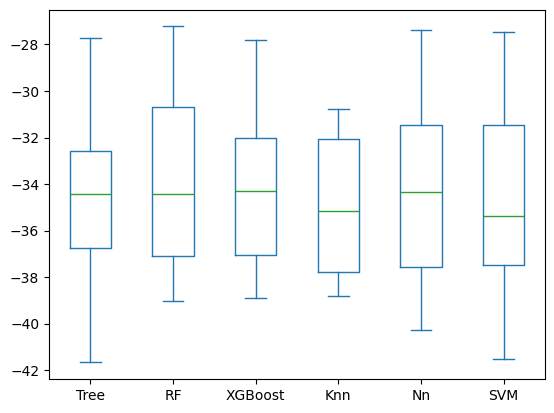

In [87]:
#Resultados de la validación cruzada
comparacion_CV.plot(kind='box')

# **Hiperparametrización con validación cruzada**

**Modelo elegido: Random Forest**

In [88]:
#Hiperparametrización
from sklearn.model_selection import GridSearchCV

scoring = ('neg_mean_absolute_error', 'neg_root_mean_squared_error', 'r2')
cv = 10

#Dataframe para comparar modelos de la hiperparametrización con validación cruzada
medidas_CV = pd.DataFrame(index=['MAE', 'RMSE', 'R2'])

In [89]:
#Variables predictoras y objetivo
X = data.drop('punt_global', axis = 1) # Variables predictoras
Y = data['punt_global'] #Variable objetivo

In [90]:
#Random Forest
from sklearn.ensemble import RandomForestRegressor
model_rf = RandomForestRegressor(random_state=3)

# Definir los hiperparametros
n_estimators = [50 ,100, 200]
max_samples = [0.05, 0.5, 0.7]
criterion = ['squared_error', 'friedman_mse']
max_depth = [5, 10, 12]
min_samples_leaf = [1, 3, 5]

In [91]:
#Hiperparametrización
param_grid = dict(criterion=criterion, n_estimators=n_estimators, max_samples=max_samples,
                  max_depth=max_depth, min_samples_leaf=min_samples_leaf)

grid = GridSearchCV(estimator=model_rf, param_grid=param_grid, scoring=scoring, cv=cv,
                    return_train_score=True, refit='neg_root_mean_squared_error', n_jobs=-1)
grid.fit(X, Y)

#Mejor modelo
model_rf = grid.best_estimator_

# Mejores párametros
print(grid.best_params_)

{'criterion': 'squared_error', 'max_depth': 10, 'max_samples': 0.5, 'min_samples_leaf': 3, 'n_estimators': 50}


In [92]:
#Revisar overfitting y underfitting
r = grid.cv_results_; i = grid.best_index_
for m in ['neg_mean_absolute_error', 'neg_root_mean_squared_error', 'r2']:
    sign = 1 if m == 'r2' else -1
    print(m, "| Train:", round(sign*r[f'mean_train_{m}'][i], 3), "| Test:", round(sign*r[f'mean_test_{m}'][i], 3))


neg_mean_absolute_error | Train: 29.817 | Test: 33.516
neg_root_mean_squared_error | Train: 37.54 | Test: 41.796
r2 | Train: 0.416 | Test: 0.163


- **MAE**
Train: 29.8 | Test: 33.5. En promedio el modelo se equivoca por ~30 unidades en train y ~34 en test.
La brecha es de ~12 %. Es moderada y no alarmante por sí sola.
- **RMSE**
Train: 37.5 | Test: 41.8.
El RMSE es mayor que el MAE (41.8 vs 33.5). Eso indica que hay algunos errores grandes que lo inflan. La relación RMSE/MAE ≈ 1.25 es normal, cercana a 1.25 si los errores son aproximadamente normales, así que no hay valores atípicos extremos.

# 4. Modelo final con todos los datos

Selección del mejor modelo:


In [93]:
modelo_final=model_rf

In [94]:

modelo_final.fit(X, Y) #100%

RandomForestRegressor(max_depth=10, max_samples=0.5, min_samples_leaf=3,
                      n_estimators=50, random_state=3)

In [95]:
import pickle
filename = 'modelo-reg.pkl'
variables=X.columns._values
pickle.dump([modelo_final, variables], open(filename, 'wb'))